# Harbour Surveillance — Multi-Sensor Simulation Environment
**Autonomous Marine Robotics — Course Project**
**DTU Department of Electrical and Photonics Engineering — CREA Group**

---

## Overview
This notebook implements the **simulation environment** for the harbour surveillance project.
It generates synthetic sensor data for five mandatory scenarios, ready to be consumed by the EKF tracker.

### Reference frame
All positions are in **NED (North-East-Down)**, 2-D. Origin = mm-wave radar position.
Bearing convention: measured from North, clockwise → `atan2(East, North)`.

### Sensor suite

| Sensor | Platform | Rate | Range | FOV | Output |
|--------|----------|------|-------|-----|--------|
| mm-wave radar | Land (NED origin) | 0.3 Hz | 1 000 m | 360° | (range, bearing) |
| Stereo camera | Land (offset) | 0.5 Hz | 500 m | 180° | (range, bearing) |
| AIS receiver | Vessel (moving) | ~1/3 Hz | 5 000 m | 360° | NED position |
| GNSS receiver | Vessel (moving) | 1 Hz | — | — | NED position |

### Scenarios
| | Description | Sensors | Duration |
|---|---|---|---|
| **A** | Single target — radar only | Radar | 120 s |
| **B** | Single target — radar + camera | Radar + Camera | 120 s |
| **C** | AIS-equipped target + dropout | All | 150 s |
| **D** | 4 targets, crossing trajectories | Radar + Camera | 120 s |
| **E** | 6 targets, mixed AIS/non-AIS | All | 180 s |


## Section 0 — Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc, FancyArrow
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
import json, os, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
np.random.seed(42)

# Output directory
OUT_DIR = Path("harbour_sim_output")
OUT_DIR.mkdir(exist_ok=True)

print("Imports OK.")
print(f"Output directory: {OUT_DIR.resolve()}")


Imports OK.
Output directory: C:\Users\jrosh\PycharmProjects\AMR\34763_AMR\harbour_sim_output


## Section 1 — Data structures

Two lightweight dataclasses carry all data through the pipeline:
- `TargetConfig` — initial kinematic state and metadata for one simulated target.
- `Measurement` — a single sensor return at a given time (true detection or false alarm).
- `SimulationOutput` — full result bundle returned by the simulation engine.


In [2]:
@dataclass
class TargetConfig:
    """Initial configuration for one simulated marine target."""
    target_id      : int
    initial_north  : float          # m, NED
    initial_east   : float          # m, NED
    velocity_north : float          # m/s
    velocity_east  : float          # m/s
    has_ais        : bool  = False  # True → target broadcasts AIS
    active_from    : float = 0.0   # s — target enters the scene at this time
    active_until   : Optional[float] = None  # s — None means stays forever


@dataclass
class Measurement:
    """One sensor return (true detection or false alarm)."""
    sensor_id     : str    # 'radar' | 'camera' | 'ais' | 'gnss'
    time          : float  # seconds since simulation start
    is_false_alarm: bool
    target_id     : int    # true target ID; -1 for false alarms / GNSS
    # Range-bearing (radar, camera) — metres / radians
    range_m       : Optional[float] = None
    bearing_rad   : Optional[float] = None
    # NED position (AIS, GNSS) — metres
    north_m       : Optional[float] = None
    east_m        : Optional[float] = None


@dataclass
class SimulationOutput:
    """Complete output of one simulation run."""
    scenario_name     : str
    dt_true           : float                    # GT propagation step [s]
    t_end             : float                    # simulation duration [s]
    ground_truth      : Dict[int, np.ndarray]    # {target_id: (T,4) states}
    ground_truth_times: np.ndarray               # (T,) time axis for GT
    measurements      : List[Measurement]        # sorted by time
    vessel_positions  : np.ndarray               # (T_gnss, 2) NED vessel pos
    vessel_times      : np.ndarray               # (T_gnss,) GNSS times
    sensor_configs    : Dict                     # parameter summary

print("Data structures defined.")


Data structures defined.


## Section 2 — Constant-velocity motion model

State vector: **x = [N, E, vN, vE]** in the NED frame.

Process noise models unmodelled accelerations (sea current, engine variation)
as white-noise accelerations with std `sigma_a` [m/s²].


In [3]:
class CVMotionModel:
    """
    Discrete-time constant-velocity model in 2-D NED.
    State: x = [p_N, p_E, v_N, v_E]  (metres, m/s)

    F  — 4×4 state transition matrix
    Q  — 4×4 process noise covariance (DWNA model)
    """
    def __init__(self, dt: float, sigma_a: float = 0.05):
        self.dt      = dt
        self.sigma_a = sigma_a
        dt2, dt3, dt4 = dt**2, dt**3, dt**4
        self._F = np.array([
            [1, 0, dt,  0],
            [0, 1,  0, dt],
            [0, 0,  1,  0],
            [0, 0,  0,  1],
        ], dtype=float)
        q = sigma_a**2
        self._Q = q * np.array([
            [dt4/4,     0, dt3/2,     0],
            [    0, dt4/4,     0, dt3/2],
            [dt3/2,     0,   dt2,     0],
            [    0, dt3/2,     0,   dt2],
        ])

    @property
    def F(self) -> np.ndarray:
        return self._F.copy()

    @property
    def Q(self) -> np.ndarray:
        return self._Q.copy()

    def propagate(self, state: np.ndarray, add_noise: bool = True) -> np.ndarray:
        """Advance state [N, E, vN, vE] forward by dt."""
        x = self._F @ state
        if add_noise:
            x += np.random.multivariate_normal(np.zeros(4), self._Q)
        return x


# ── Sanity check ──────────────────────────────────────────────────────────────
_m = CVMotionModel(dt=1.0, sigma_a=0.1)
_x = np.array([0., 0., 2., 1.])
_x2 = _m.propagate(_x, add_noise=False)
assert abs(_x2[0] - 2.0) < 1e-9 and abs(_x2[1] - 1.0) < 1e-9, "CV propagation failed"
print(f"CV model OK  |  F[0,2]={_m.F[0,2]}, F[1,3]={_m.F[1,3]}  (both should equal dt=1.0)")
print(f"Q diagonal: {np.diag(_m.Q).round(6)}  (should be [0.0025, 0.0025, 0.01, 0.01])")


CV model OK  |  F[0,2]=1.0, F[1,3]=1.0  (both should equal dt=1.0)
Q diagonal: [0.0025 0.0025 0.01   0.01  ]  (should be [0.0025, 0.0025, 0.01, 0.01])


## Section 3 — Sensor models

### Coordinate convention
All sensors produce measurements expressed in the NED frame.
Bearing is measured **from North, clockwise**: `φ = atan2(ΔE, ΔN)`.

### Sensor positions
- **Radar**: NED origin `[0, 0]` — measurement model reduces to the Exercise 1 model exactly.
- **Stereo camera**: known NED offset `s_c = [-80, 120]` m from the radar.
- **AIS**: vessel position `v(t)` from the GNSS fix (time-varying offset).


In [4]:
# ── Shared helpers ─────────────────────────────────────────────────────────────

def wrap_angle(a: float) -> float:
    """Wrap angle to (−π, π]."""
    return (a + np.pi) % (2 * np.pi) - np.pi


def range_bearing(sensor_ned: np.ndarray, target_ned: np.ndarray
                  ) -> Tuple[float, float]:
    """
    (range [m], bearing [rad]) from sensor to target in NED.
    bearing = atan2(ΔEast, ΔNorth)  — from North, clockwise.
    """
    d   = target_ned - sensor_ned
    r   = float(np.linalg.norm(d))
    phi = float(np.arctan2(d[1], d[0]))   # atan2(East, North)
    return r, phi


# ══════════════════════════════════════════════════════════════════════════════
class RadarSensor:
    """
    mm-wave radar — land-based, NED origin [0, 0].

    Rate  : 0.3 Hz  (scan every 1/0.3 ≈ 3.33 s)
    Range : 1 000 m
    FOV   : 360°
    Output: (range [m], bearing [rad])
    Noise : σ_r [m], σ_φ [rad], independent
    """
    SENSOR_ID = "radar"

    def __init__(self,
                 sigma_r    : float = 5.0,
                 sigma_phi  : float = np.deg2rad(0.3),
                 range_max  : float = 1000.0,
                 update_rate: float = 0.3,
                 pd         : float = 0.95,
                 lambda_fa  : float = 3.0):
        self.pos_ned     = np.array([0.0, 0.0])
        self.sigma_r     = sigma_r
        self.sigma_phi   = sigma_phi
        self.range_max   = range_max
        self.update_rate = update_rate
        self.dt_scan     = 1.0 / update_rate
        self.pd          = pd
        self.lambda_fa   = lambda_fa

    # FOV check (360° — only range gate)
    def in_fov(self, target_ned: np.ndarray) -> bool:
        return np.linalg.norm(target_ned - self.pos_ned) <= self.range_max

    # Noisy measurement
    def measure(self, target_ned: np.ndarray) -> Tuple[float, float]:
        r, phi = range_bearing(self.pos_ned, target_ned)
        r_m    = r   + np.random.randn() * self.sigma_r
        phi_m  = phi + np.random.randn() * self.sigma_phi
        return max(0.0, r_m), wrap_angle(phi_m)

    # Clutter returns (uniform in range × azimuth)
    def false_alarms(self) -> List[Tuple[float, float]]:
        fa = []
        for _ in range(np.random.poisson(self.lambda_fa)):
            r   = np.random.uniform(0, self.range_max)
            phi = np.random.uniform(-np.pi, np.pi)
            fa.append((r, phi))
        return fa

    @property
    def R(self) -> np.ndarray:
        """2×2 measurement noise covariance."""
        return np.diag([self.sigma_r**2, self.sigma_phi**2])


# ══════════════════════════════════════════════════════════════════════════════
class StereoCameraSensor:
    """
    Stereo RGB camera — land-based, configurable NED offset.

    Rate  : 0.5 Hz  (frame every 2 s)
    Range : 500 m
    FOV   : 180°  (configurable boresight direction)
    Output: (range [m], bearing [rad])
    Noise : σ_r [m], σ_φ [rad], independent
    """
    SENSOR_ID = "camera"

    def __init__(self,
                 pos_ned      : np.ndarray = np.array([-80.0, 120.0]),
                 boresight_rad: float      = np.deg2rad(45.0),
                 sigma_r      : float      = 8.0,
                 sigma_phi    : float      = np.deg2rad(0.15),
                 range_max    : float      = 500.0,
                 update_rate  : float      = 0.5,
                 pd           : float      = 0.90,
                 lambda_fa    : float      = 2.0):
        self.pos_ned     = np.asarray(pos_ned, dtype=float)
        self.boresight   = boresight_rad
        self.half_fov    = np.pi / 2            # ±90° → 180° total
        self.sigma_r     = sigma_r
        self.sigma_phi   = sigma_phi
        self.range_max   = range_max
        self.update_rate = update_rate
        self.dt_scan     = 1.0 / update_rate
        self.pd          = pd
        self.lambda_fa   = lambda_fa

    def in_fov(self, target_ned: np.ndarray) -> bool:
        r, phi = range_bearing(self.pos_ned, target_ned)
        if r > self.range_max:
            return False
        return abs(wrap_angle(phi - self.boresight)) <= self.half_fov

    def measure(self, target_ned: np.ndarray) -> Tuple[float, float]:
        r, phi = range_bearing(self.pos_ned, target_ned)
        r_m    = r   + np.random.randn() * self.sigma_r
        phi_m  = phi + np.random.randn() * self.sigma_phi
        return max(0.0, r_m), wrap_angle(phi_m)

    def false_alarms(self) -> List[Tuple[float, float]]:
        fa = []
        for _ in range(np.random.poisson(self.lambda_fa)):
            r   = np.random.uniform(0, self.range_max)
            phi = self.boresight + np.random.uniform(-self.half_fov, self.half_fov)
            fa.append((r, wrap_angle(phi)))
        return fa

    @property
    def R(self) -> np.ndarray:
        return np.diag([self.sigma_r**2, self.sigma_phi**2])


# ══════════════════════════════════════════════════════════════════════════════
class AISSensor:
    """
    AIS receiver — mounted on the moving vessel.

    Rate  : one report per 3 s
    Range : 5 000 m from vessel
    FOV   : 360°
    Output: NED position [N, E] — NOT range-bearing
    Only AIS-equipped targets (has_ais=True) generate reports.
    """
    SENSOR_ID = "ais"

    def __init__(self,
                 sigma_pos       : float = 4.0,
                 range_max       : float = 5000.0,
                 report_interval : float = 3.0,
                 pd              : float = 0.98,
                 lambda_fa       : float = 0.2):
        self.sigma_pos       = sigma_pos
        self.range_max       = range_max
        self.report_interval = report_interval
        self.dt_scan         = report_interval
        self.update_rate     = 1.0 / report_interval
        self.pd              = pd
        self.lambda_fa       = lambda_fa

    def in_range(self, vessel_ned: np.ndarray, target_ned: np.ndarray) -> bool:
        return np.linalg.norm(target_ned - vessel_ned) <= self.range_max

    def measure(self, target_ned: np.ndarray) -> Tuple[float, float]:
        """Returns noisy NED position (N, E) of target."""
        noise = np.random.randn(2) * self.sigma_pos
        return float(target_ned[0] + noise[0]), float(target_ned[1] + noise[1])

    def false_alarms(self, vessel_ned: np.ndarray) -> List[Tuple[float, float]]:
        """Ghost AIS contacts (spoofing, relay artefacts)."""
        fa = []
        for _ in range(np.random.poisson(self.lambda_fa)):
            r   = np.random.uniform(0, self.range_max)
            phi = np.random.uniform(-np.pi, np.pi)
            fa.append((float(vessel_ned[0] + r * np.cos(phi)),
                       float(vessel_ned[1] + r * np.sin(phi))))
        return fa

    @property
    def R(self) -> np.ndarray:
        """2×2 position noise covariance."""
        return np.diag([self.sigma_pos**2, self.sigma_pos**2])


# ══════════════════════════════════════════════════════════════════════════════
class GNSSSensor:
    """GNSS receiver — vessel own-position in NED, 1 Hz."""
    SENSOR_ID = "gnss"

    def __init__(self, sigma_pos: float = 2.0, update_rate: float = 1.0):
        self.sigma_pos   = sigma_pos
        self.update_rate = update_rate
        self.dt_scan     = 1.0 / update_rate

    def measure(self, vessel_ned: np.ndarray) -> Tuple[float, float]:
        noise = np.random.randn(2) * self.sigma_pos
        return float(vessel_ned[0] + noise[0]), float(vessel_ned[1] + noise[1])

    @property
    def R(self) -> np.ndarray:
        return np.diag([self.sigma_pos**2, self.sigma_pos**2])


# ── Quick unit tests ──────────────────────────────────────────────────────────
_r = RadarSensor()
_p_target = np.array([300.0, 400.0])
_rr, _phi = range_bearing(_r.pos_ned, _p_target)
assert abs(_rr - 500.0) < 1e-6, "range_bearing failed"
assert abs(_phi - np.arctan2(400, 300)) < 1e-9, "bearing failed"
assert _r.in_fov(_p_target), "FOV check failed"
assert not _r.in_fov(np.array([900.0, 900.0])), "range gate failed"
print("Sensor models OK.")
print(f"  Radar origin: {_r.pos_ned}  (NED, should be [0,0])")
_c = StereoCameraSensor()
print(f"  Camera offset: {_c.pos_ned} m NED,  boresight: {np.rad2deg(_c.boresight):.1f}°")


Sensor models OK.
  Radar origin: [0. 0.]  (NED, should be [0,0])
  Camera offset: [-80. 120.] m NED,  boresight: 45.0°


## Section 4 — Vessel patrol trajectory

The surface vessel follows a closed patrol route around the harbour entrance.
Position at any time `t` is interpolated along the route at constant speed.
The route loops continuously throughout the simulation.


In [5]:
class VesselTrajectory:
    """
    Closed patrol route for the surface vessel.
    Vessel moves between NED waypoints at constant speed and loops.
    """
    KNOTS_TO_MS = 0.514444

    def __init__(self, waypoints: List[List[float]], speed_knots: float = 3.0):
        self.waypoints = [np.asarray(wp, dtype=float) for wp in waypoints]
        self.speed_ms  = speed_knots * self.KNOTS_TO_MS
        self._segs     = self._build_segments()
        self.total_duration = sum(s["dur"] for s in self._segs)

    def _build_segments(self):
        wps = self.waypoints + [self.waypoints[0]]   # close the loop
        segs, t0 = [], 0.0
        for i in range(len(wps) - 1):
            d   = wps[i+1] - wps[i]
            dist = np.linalg.norm(d)
            if dist < 1e-6:
                continue
            dur = dist / self.speed_ms
            segs.append({"p0": wps[i].copy(), "dir": d/dist, "dur": dur, "t0": t0})
            t0 += dur
        return segs

    def position(self, t: float) -> np.ndarray:
        """Vessel NED position at time t [s] — loops the route."""
        t = t % self.total_duration
        for s in self._segs:
            dt = t - s["t0"]
            if dt <= s["dur"] + 1e-9:
                return s["p0"] + max(0.0, dt) * self.speed_ms * s["dir"]
        last = self._segs[-1]
        return last["p0"] + last["dur"] * self.speed_ms * last["dir"]


# Default harbour patrol route (NED, metres)
DEFAULT_PATROL = [
    [ 300,  800],
    [ 600,  600],
    [ 700,  200],
    [ 500, -200],
    [ 200, -300],
    [-100,  -50],
    [ 100,  400],
]

_v = VesselTrajectory(DEFAULT_PATROL, speed_knots=3.0)
print(f"Vessel route OK  |  loop duration = {_v.total_duration:.1f} s  "
      f"({_v.total_duration/60:.1f} min)  |  speed = {_v.speed_ms:.2f} m/s (3 kn)")
print(f"  Position at t=0  : {_v.position(0.0).round(1)} m NED")
print(f"  Position at t=60 : {_v.position(60.0).round(1)} m NED")


Vessel route OK  |  loop duration = 1857.3 s  (31.0 min)  |  speed = 1.54 m/s (3 kn)
  Position at t=0  : [300. 800.] m NED
  Position at t=60 : [377.  748.6] m NED


## Section 5 — Simulation engine

`HarbourSimulation.run()` is the main entry point. It:
1. Propagates all target ground-truth trajectories at `DT_TRUE = 0.1 s`.
2. At each sensor's scheduled scan time, generates noisy measurements and false alarms.
3. Handles AIS dropout windows, target activation/deactivation, and vessel motion.
4. Returns a fully self-contained `SimulationOutput` bundle.


In [6]:
class HarbourSimulation:
    """
    Multi-sensor, multi-target harbour surveillance simulator.

    NED frame — origin at mm-wave radar. Bearing: atan2(East, North).

    Parameters
    ----------
    radar, camera, ais, gnss : sensor objects (Sections 3)
    vessel                   : VesselTrajectory (Section 4)
    """

    DT_TRUE = 1.0/30.0   # ground-truth propagation step [s]
                         #   Must divide evenly into every sensor period:
                         #   Radar    1/0.3  s = 100 × DT_TRUE
                         #   Camera 1/0.5  s =   60 × DT_TRUE
                         #   GNSS    1.0      s =   30 × DT_TRUE
                         #   AIS        3.0      s = 100 × DT_TRUE

    def __init__(self,
                 radar  : RadarSensor,
                 camera : StereoCameraSensor,
                 ais    : AISSensor,
                 gnss   : GNSSSensor,
                 vessel : VesselTrajectory):
        self.radar  = radar
        self.camera = camera
        self.ais    = ais
        self.gnss   = gnss
        self.vessel = vessel
        self.motion = CVMotionModel(dt=self.DT_TRUE, sigma_a=0.05)

    # ── helpers ────────────────────────────────────────────────────────────────
    @staticmethod
    def _scan_grid(t_end: float, dt_scan: float) -> set:
        """Set of scan-trigger times in (0, t_end], rounded to avoid float drift."""
        times = np.arange(dt_scan, t_end + 1e-9, dt_scan)
        return set(np.round(times, 6))

    # ── main run ───────────────────────────────────────────────────────────────
    def run(self,
            targets        : List[TargetConfig],
            t_end          : float,
            scenario_name  : str = "unnamed",
            active_sensors : Optional[List[str]] = None,
            ais_dropout    : Optional[Tuple[float, float]] = None
            ) -> SimulationOutput:
        """
        Run the simulation and return a SimulationOutput.

        Parameters
        ----------
        targets        : list of TargetConfig
        t_end          : simulation duration [s]
        scenario_name  : label for plots / export
        active_sensors : sensor IDs to activate; None = all four
        ais_dropout    : (t_start, t_end) AIS blackout window
        """
        if active_sensors is None:
            active_sensors = ["radar", "camera", "ais", "gnss"]

        dt = self.DT_TRUE
        t_grid  = np.round(np.arange(0.0, t_end + dt/2, dt), 6)
        n_steps = len(t_grid)

        # Per-sensor scan schedules (sets for O(1) lookup)
        sched = {
            "radar" : self._scan_grid(t_end, self.radar.dt_scan),
            "camera": self._scan_grid(t_end, self.camera.dt_scan),
            "ais"   : self._scan_grid(t_end, self.ais.dt_scan),
            "gnss"  : self._scan_grid(t_end, self.gnss.dt_scan),
        }

        # Ground-truth arrays
        states = {cfg.target_id: np.array([cfg.initial_north, cfg.initial_east,
                                           cfg.velocity_north, cfg.velocity_east],
                                          dtype=float)
                  for cfg in targets}
        gt     = {cfg.target_id: np.full((n_steps, 4), np.nan) for cfg in targets}
        alive  = {cfg.target_id: False for cfg in targets}

        measurements     = []
        vessel_positions = []
        vessel_times_out = []

        for step, t in enumerate(t_grid):
            t_r        = float(t)
            vessel_pos = self.vessel.position(t_r)

            # ── Propagate targets ──────────────────────────────────────────────
            for cfg in targets:
                tid = cfg.target_id
                is_active = (t_r >= cfg.active_from and
                             (cfg.active_until is None or t_r < cfg.active_until))
                if is_active:
                    if not alive[tid]:
                        alive[tid] = True   # first activation: keep initial state
                    elif step > 0:
                        states[tid] = self.motion.propagate(states[tid], add_noise=True)
                    gt[tid][step] = states[tid].copy()
                else:
                    alive[tid] = False
                    # gt stays NaN

            # ── GNSS fix ──────────────────────────────────────────────────────
            if "gnss" in active_sensors and t_r in sched["gnss"]:
                n_m, e_m = self.gnss.measure(vessel_pos)
                measurements.append(Measurement(
                    sensor_id="gnss", time=t_r, is_false_alarm=False,
                    target_id=-1, north_m=n_m, east_m=e_m))
                vessel_positions.append(vessel_pos.copy())
                vessel_times_out.append(t_r)

            # ── Radar scan ────────────────────────────────────────────────────
            if "radar" in active_sensors and t_r in sched["radar"]:
                for cfg in targets:
                    tid = cfg.target_id
                    if alive[tid] and self.radar.in_fov(states[tid][:2]):
                        if np.random.rand() < self.radar.pd:
                            r, phi = self.radar.measure(states[tid][:2])
                            measurements.append(Measurement(
                                sensor_id="radar", time=t_r, is_false_alarm=False,
                                target_id=tid, range_m=r, bearing_rad=phi))
                for r, phi in self.radar.false_alarms():
                    measurements.append(Measurement(
                        sensor_id="radar", time=t_r, is_false_alarm=True,
                        target_id=-1, range_m=r, bearing_rad=phi))

            # ── Camera scan ───────────────────────────────────────────────────
            if "camera" in active_sensors and t_r in sched["camera"]:
                for cfg in targets:
                    tid = cfg.target_id
                    if alive[tid] and self.camera.in_fov(states[tid][:2]):
                        if np.random.rand() < self.camera.pd:
                            r, phi = self.camera.measure(states[tid][:2])
                            measurements.append(Measurement(
                                sensor_id="camera", time=t_r, is_false_alarm=False,
                                target_id=tid, range_m=r, bearing_rad=phi))
                for r, phi in self.camera.false_alarms():
                    measurements.append(Measurement(
                        sensor_id="camera", time=t_r, is_false_alarm=True,
                        target_id=-1, range_m=r, bearing_rad=phi))

            # ── AIS reports ───────────────────────────────────────────────────
            if "ais" in active_sensors and t_r in sched["ais"]:
                in_dropout = (ais_dropout is not None and
                              ais_dropout[0] <= t_r <= ais_dropout[1])
                if not in_dropout:
                    for cfg in targets:
                        tid = cfg.target_id
                        if not cfg.has_ais or not alive[tid]:
                            continue
                        if not self.ais.in_range(vessel_pos, states[tid][:2]):
                            continue
                        if np.random.rand() < self.ais.pd:
                            n_m, e_m = self.ais.measure(states[tid][:2])
                            measurements.append(Measurement(
                                sensor_id="ais", time=t_r, is_false_alarm=False,
                                target_id=tid, north_m=n_m, east_m=e_m))
                    for n_m, e_m in self.ais.false_alarms(vessel_pos):
                        measurements.append(Measurement(
                            sensor_id="ais", time=t_r, is_false_alarm=True,
                            target_id=-1, north_m=n_m, east_m=e_m))

        measurements.sort(key=lambda m: m.time)

        return SimulationOutput(
            scenario_name      = scenario_name,
            dt_true            = dt,
            t_end              = t_end,
            ground_truth       = gt,
            ground_truth_times = t_grid,
            measurements       = measurements,
            vessel_positions   = np.array(vessel_positions) if vessel_positions
                                 else np.zeros((0, 2)),
            vessel_times       = np.array(vessel_times_out),
            sensor_configs     = self._sensor_summary(),
        )

    def _sensor_summary(self) -> Dict:
        return {
            "radar":  {"pos_ned"      : self.radar.pos_ned.tolist(),
                       "range_m"      : self.radar.range_max,
                       "fov_deg"      : 360,
                       "rate_hz"      : self.radar.update_rate,
                       "sigma_r_m"    : self.radar.sigma_r,
                       "sigma_phi_deg": np.rad2deg(self.radar.sigma_phi),
                       "pd"           : self.radar.pd,
                       "lambda_fa"    : self.radar.lambda_fa},
            "camera": {"pos_ned"      : self.camera.pos_ned.tolist(),
                       "boresight_deg": np.rad2deg(self.camera.boresight),
                       "range_m"      : self.camera.range_max,
                       "fov_deg"      : 180,
                       "rate_hz"      : self.camera.update_rate,
                       "sigma_r_m"    : self.camera.sigma_r,
                       "sigma_phi_deg": np.rad2deg(self.camera.sigma_phi),
                       "pd"           : self.camera.pd,
                       "lambda_fa"    : self.camera.lambda_fa},
            "ais":    {"range_m"      : self.ais.range_max,
                       "interval_s"   : self.ais.report_interval,
                       "sigma_pos_m"  : self.ais.sigma_pos,
                       "pd"           : self.ais.pd},
            "gnss":   {"sigma_pos_m"  : self.gnss.sigma_pos,
                       "rate_hz"      : self.gnss.update_rate},
        }


print("Simulation engine defined.")


Simulation engine defined.


## Section 6 — Visualisation utilities

In [7]:
SENSOR_COLORS = {
    "radar" : "#2E75B6",
    "camera": "#0B6E4F",
    "ais"   : "#BA7517",
    "gnss"  : "#7F77DD",
}
TARGET_COLORS = plt.cm.tab10


def _meas_to_ned(m: Measurement, cam_pos: np.ndarray) -> Optional[Tuple[float, float]]:
    """Convert a measurement back to NED East/North for plotting."""
    if m.sensor_id == "radar" and m.range_m is not None:
        n = m.range_m * np.cos(m.bearing_rad)
        e = m.range_m * np.sin(m.bearing_rad)
        return e, n
    if m.sensor_id == "camera" and m.range_m is not None:
        n = cam_pos[0] + m.range_m * np.cos(m.bearing_rad)
        e = cam_pos[1] + m.range_m * np.sin(m.bearing_rad)
        return e, n
    if m.sensor_id == "ais" and m.north_m is not None:
        return m.east_m, m.north_m
    return None


def plot_scenario(output: SimulationOutput,
                  ais_dropout: Optional[Tuple[float, float]] = None,
                  figsize: Tuple = (15, 10)):
    """
    Four-panel visualisation of a simulation output:
    - Top-left  : 2-D NED scene (trajectories + measurements)
    - Top-right : Range over time per sensor
    - Bottom-left: Bearing over time per sensor
    - Bottom-right: Measurement count per scan
    """
    cfg     = output.sensor_configs
    cam_pos = np.asarray(cfg["camera"]["pos_ned"])
    t_grid  = output.ground_truth_times
    t_ids   = sorted(output.ground_truth.keys())

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    ax_scene, ax_range = axes[0]
    ax_bear,  ax_cnt   = axes[1]

    # ── 2-D NED scene ─────────────────────────────────────────────────────────
    ax = ax_scene

    # Radar coverage circle
    ax.add_patch(plt.Circle((0, 0), cfg["radar"]["range_m"],
                             fill=False, color=SENSOR_COLORS["radar"],
                             ls="--", lw=1.0, alpha=0.45, label="Radar FOV"))
    ax.plot(0, 0, "^", color=SENSOR_COLORS["radar"], ms=11, zorder=6)
    ax.annotate("Radar\n(NED origin)", (15, 15), fontsize=8, color=SENSOR_COLORS["radar"])

    # Camera coverage arc (in East-North axes: x=E, y=N)
    bs   = cfg["camera"]["boresight_deg"]
    cr   = cfg["camera"]["range_m"]
    arc  = Arc((cam_pos[1], cam_pos[0]), 2*cr, 2*cr,
               angle=0, theta1=90-bs-90, theta2=90-bs+90,
               color=SENSOR_COLORS["camera"], lw=1.0, ls="--", alpha=0.45,
               label="Camera FOV")
    ax.add_patch(arc)
    ax.plot(cam_pos[1], cam_pos[0], "s", color=SENSOR_COLORS["camera"], ms=9, zorder=6)
    ax.annotate("Camera", (cam_pos[1]+20, cam_pos[0]+20), fontsize=8,
                color=SENSOR_COLORS["camera"])

    # Vessel route
    if len(output.vessel_times) > 0:
        ax.plot(output.vessel_positions[:, 1], output.vessel_positions[:, 0],
                ":", color=SENSOR_COLORS["gnss"], lw=1.5, alpha=0.7, label="Vessel route")

    # Ground-truth trajectories
    for i, tid in enumerate(t_ids):
        gt  = output.ground_truth[tid]
        col = TARGET_COLORS(i / max(len(t_ids), 1))
        valid = ~np.isnan(gt[:, 0])
        ax.plot(gt[valid, 1], gt[valid, 0], "-", color=col, lw=2.0,
                label=f"Target {tid}", zorder=4)
        idx = np.where(valid)[0]
        if len(idx):
            ax.plot(gt[idx[0],  1], gt[idx[0],  0], "o", color=col, ms=8, zorder=5)
            ax.plot(gt[idx[-1], 1], gt[idx[-1], 0], "D", color=col, ms=7, zorder=5)
            if len(idx) > 10:
                m = idx[len(idx)//2]
                ax.annotate("", xy=(gt[m+1,1], gt[m+1,0]),
                            xytext=(gt[m-1,1], gt[m-1,0]),
                            arrowprops=dict(arrowstyle="->", color=col, lw=1.4))

    # Measurements (true detections + false alarms)
    for m in output.measurements:
        if m.sensor_id == "gnss":
            continue
        ne = _meas_to_ned(m, cam_pos)
        if ne is None:
            continue
        col   = SENSOR_COLORS.get(m.sensor_id, "#888888")
        mk    = "x" if m.is_false_alarm else "."
        alpha = 0.25 if m.is_false_alarm else 0.5
        ms    = 5 if m.is_false_alarm else 6
        ax.plot(ne[0], ne[1], mk, color=col, ms=ms, alpha=alpha, zorder=3)

    ax.set_xlabel("East [m]", fontsize=10)
    ax.set_ylabel("North [m]", fontsize=10)
    ax.set_title(f"Scenario {output.scenario_name} — 2-D NED", fontsize=11, fontweight="bold")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.28)
    ax.legend(fontsize=7, loc="best", ncol=2)

    # ── Range over time ────────────────────────────────────────────────────────
    ax = ax_range
    for sid in ["radar", "camera"]:
        col = SENSOR_COLORS[sid]
        for m in output.measurements:
            if m.sensor_id != sid or m.range_m is None:
                continue
            al = 0.2 if m.is_false_alarm else 0.55
            ax.plot(m.time, m.range_m, ".", color=col, ms=3, alpha=al)
        ax.plot([], [], ".", color=col, label=sid.capitalize(), ms=6)
    if ais_dropout:
        ax.axvspan(*ais_dropout, alpha=0.15, color="red", label="AIS dropout")
    ax.set_xlabel("Time [s]", fontsize=9)
    ax.set_ylabel("Range [m]", fontsize=9)
    ax.set_title("Range measurements", fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.28)

    # ── Bearing over time ──────────────────────────────────────────────────────
    ax = ax_bear
    for sid in ["radar", "camera"]:
        col = SENSOR_COLORS[sid]
        for m in output.measurements:
            if m.sensor_id != sid or m.bearing_rad is None:
                continue
            al = 0.2 if m.is_false_alarm else 0.55
            ax.plot(m.time, np.rad2deg(m.bearing_rad), ".", color=col, ms=3, alpha=al)
        ax.plot([], [], ".", color=col, label=sid.capitalize(), ms=6)
    ax.set_xlabel("Time [s]", fontsize=9)
    ax.set_ylabel("Bearing [°]", fontsize=9)
    ax.set_title("Bearing measurements", fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.28)

    # ── Detections per scan ────────────────────────────────────────────────────
    ax = ax_cnt
    for sid in ["radar", "camera", "ais"]:
        col  = SENSOR_COLORS[sid]
        true_meas = [m for m in output.measurements
                     if m.sensor_id == sid and not m.is_false_alarm]
        if not true_meas:
            continue
        scan_t = sorted(set(m.time for m in true_meas))
        cnts   = [sum(1 for m in true_meas if m.time == t) for t in scan_t]
        ax.step(scan_t, cnts, where="post", color=col, lw=1.8,
                label=sid.capitalize(), alpha=0.85)
    if ais_dropout:
        ax.axvspan(*ais_dropout, alpha=0.15, color="red", label="AIS dropout")
    ax.set_xlabel("Time [s]", fontsize=9)
    ax.set_ylabel("True det. per scan", fontsize=9)
    ax.set_title("True detections per scan", fontsize=10)
    ax.yaxis.get_major_locator().set_params(integer=True)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.28)

    plt.suptitle(f"Harbour Surveillance Simulation — Scenario {output.scenario_name}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname = OUT_DIR / f"scenario_{output.scenario_name}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")


def print_summary(output: SimulationOutput):
    """Print a compact statistics table for one simulation output."""
    by_s, fa_s = {}, {}
    for m in output.measurements:
        by_s[m.sensor_id] = by_s.get(m.sensor_id, 0) + 1
        if m.is_false_alarm:
            fa_s[m.sensor_id] = fa_s.get(m.sensor_id, 0) + 1

    active_tgts = sum(
        1 for tid, gt in output.ground_truth.items()
        if not np.all(np.isnan(gt[:, 0]))
    )
    print(f"\n{'═'*58}")
    print(f"  Scenario {output.scenario_name:<4}  |  "
          f"duration: {output.t_end} s  |  targets: {active_tgts}")
    print(f"{'─'*58}")
    print(f"  {'Sensor':<10} {'Total':>7} {'True det.':>10} {'False alarms':>13}")
    print(f"{'─'*58}")
    for sid in ["radar", "camera", "ais", "gnss"]:
        tot  = by_s.get(sid, 0)
        fa   = fa_s.get(sid, 0)
        true = tot - fa
        print(f"  {sid:<10} {tot:>7} {true:>10} {fa:>13}")
    print(f"{'═'*58}\n")


print("Visualisation utilities defined.")


Visualisation utilities defined.


## Section 7 — Data export utilities

All simulation outputs are saved as structured JSON files.
This format is directly readable by the EKF tracker implementation.

### JSON schema
```
{
  "scenario_name": str,
  "t_end": float,
  "sensor_configs": { ... },
  "ground_truth": {
      "target_id": [[t, N, E, vN, vE], ...]   ← only active steps
  },
  "measurements": [
      {"sensor_id", "time", "is_false_alarm", "target_id",
       "range_m"|null, "bearing_rad"|null, "north_m"|null, "east_m"|null},
      ...
  ],
  "vessel_positions": [[t, N, E], ...]
}
```


In [8]:
def export_json(output: SimulationOutput, path: Optional[str] = None) -> str:
    """Export SimulationOutput to JSON. Returns the file path."""
    if path is None:
        path = str(OUT_DIR / f"scenario_{output.scenario_name}.json")

    # Ground truth — only non-NaN rows
    gt_exp = {}
    for tid, gt in output.ground_truth.items():
        rows = []
        for step, t in enumerate(output.ground_truth_times):
            if not np.isnan(gt[step, 0]):
                row = [round(float(t), 4)] + [round(float(v), 4) for v in gt[step]]
                rows.append(row)
        gt_exp[str(tid)] = rows

    # Measurements
    meas_exp = [{
        "sensor_id"     : m.sensor_id,
        "time"          : round(m.time, 4),
        "is_false_alarm": m.is_false_alarm,
        "target_id"     : m.target_id,
        "range_m"       : round(m.range_m,    4) if m.range_m    is not None else None,
        "bearing_rad"   : round(m.bearing_rad, 6) if m.bearing_rad is not None else None,
        "north_m"       : round(m.north_m,    4) if m.north_m    is not None else None,
        "east_m"        : round(m.east_m,     4) if m.east_m     is not None else None,
    } for m in output.measurements]

    # Vessel positions
    vp_exp = [[round(float(t),4), round(float(p[0]),4), round(float(p[1]),4)]
              for t, p in zip(output.vessel_times, output.vessel_positions)]

    data = {
        "scenario_name"  : output.scenario_name,
        "t_end"          : output.t_end,
        "dt_true"        : output.dt_true,
        "sensor_configs" : output.sensor_configs,
        "ground_truth"   : gt_exp,
        "measurements"   : meas_exp,
        "vessel_positions": vp_exp,
    }

    with open(path, "w") as f:
        json.dump(data, f, indent=2)

    size_kb = os.path.getsize(path) / 1024
    print(f"  Exported {path}  ({size_kb:.1f} kB, "
          f"{len(meas_exp)} measurements)")
    return path


def load_json(path: str) -> dict:
    """Load a previously exported scenario JSON."""
    with open(path) as f:
        data = json.load(f)
    print(f"  Loaded  {path}  ({len(data['measurements'])} measurements)")
    return data


print("Export utilities defined.")


Export utilities defined.


## Section 8 — Default sensor and vessel factory

All five scenarios share the same base sensor parameters (project defaults).
Scenario-specific overrides are applied locally inside each scenario cell.


In [9]:
def make_sensors(radar_pd=0.95, radar_lfa=3.0,
                 camera_pd=0.90, camera_lfa=2.0,
                 ais_pd=0.98,    ais_lfa=0.2):
    """Instantiate all four sensors with project-default parameters.
    pd / lambda_fa arguments allow per-scenario overrides."""
    radar = RadarSensor(
        sigma_r=5.0, sigma_phi=np.deg2rad(0.3),
        range_max=1000.0, update_rate=0.3,
        pd=radar_pd, lambda_fa=radar_lfa,
    )
    camera = StereoCameraSensor(
        pos_ned=np.array([-80.0, 120.0]),
        boresight_rad=np.deg2rad(45.0),   # NE direction
        sigma_r=8.0, sigma_phi=np.deg2rad(0.15),
        range_max=500.0, update_rate=0.5,
        pd=camera_pd, lambda_fa=camera_lfa,
    )
    ais = AISSensor(
        sigma_pos=4.0, range_max=5000.0,
        report_interval=3.0,
        pd=ais_pd, lambda_fa=ais_lfa,
    )
    gnss = GNSSSensor(sigma_pos=2.0, update_rate=1.0)
    return radar, camera, ais, gnss


def make_sim():
    """Build a fresh simulation engine with default sensors and vessel."""
    r, c, a, g = make_sensors()
    v = VesselTrajectory(DEFAULT_PATROL, speed_knots=3.0)
    return HarbourSimulation(r, c, a, g, v)


print("Factory functions defined.")


Factory functions defined.


---
## Scenario A — Single target, radar only

**Purpose**: validate EKF correctness, NIS consistency, and track lifecycle
with the simplest possible setup. Only the radar is active.

**Success criteria**:
- Track confirmed within 5 radar scans (≈17 s).
- Steady-state position RMSE < 12 m.
- ≥ 90 % of NIS values within the 95 % χ²(2) bounds.



══════════════════════════════════════════════════════════
  Scenario A     |  duration: 120.0 s  |  targets: 1
──────────────────────────────────────────────────────────
  Sensor       Total  True det.  False alarms
──────────────────────────────────────────────────────────
  radar          143         33           110
  camera           0          0             0
  ais              0          0             0
  gnss           120        120             0
══════════════════════════════════════════════════════════



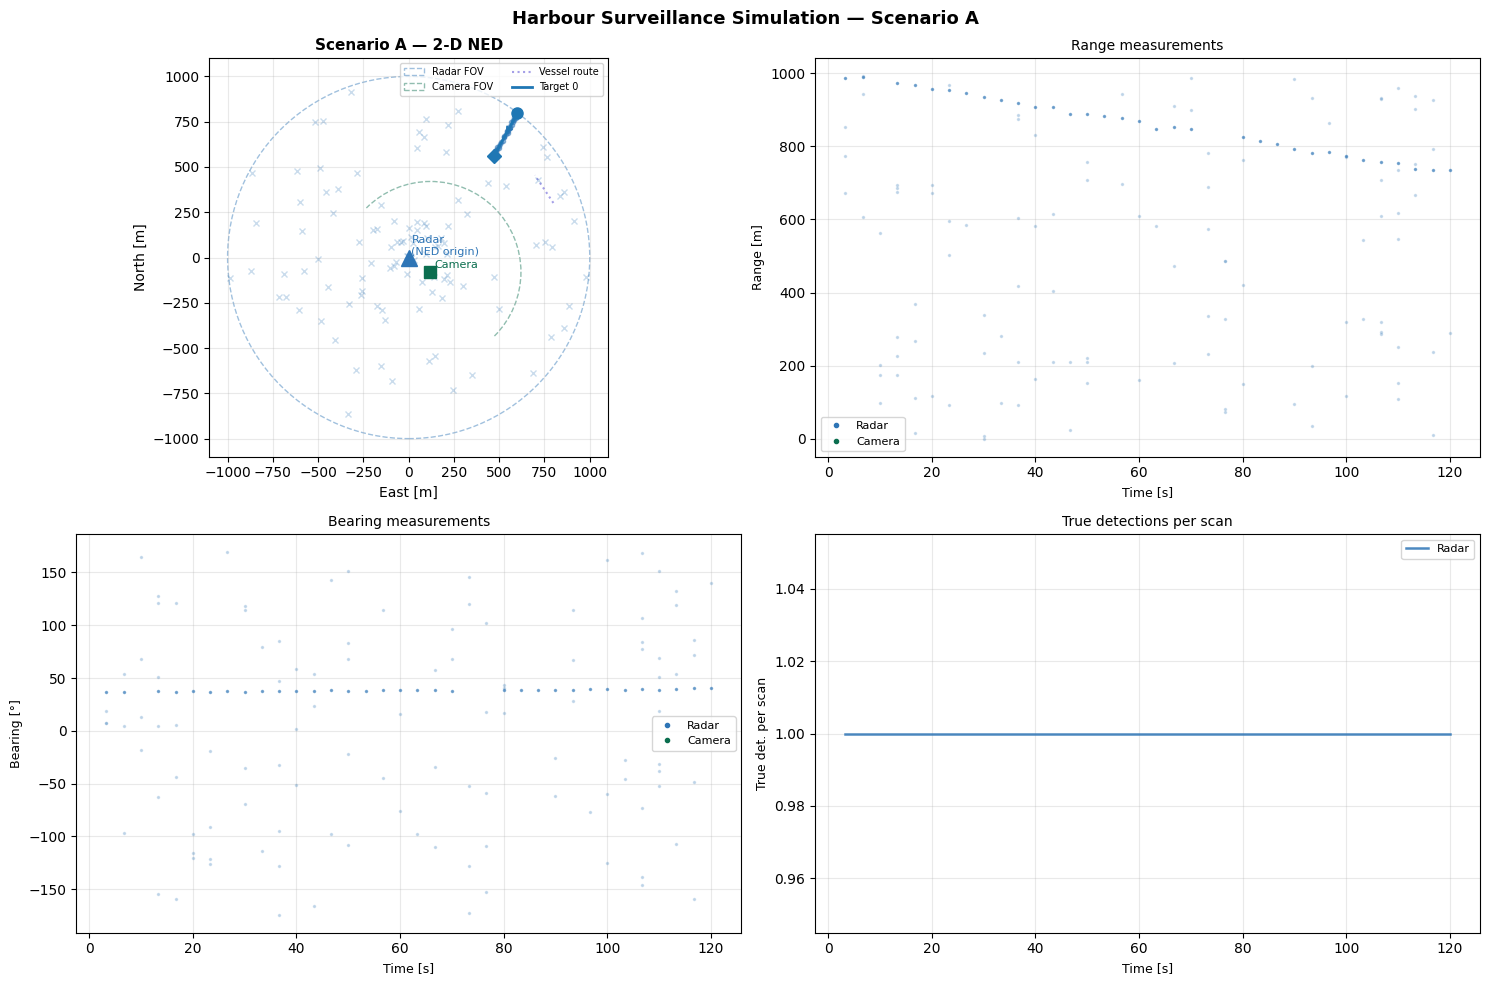

  Saved: harbour_sim_output\scenario_A.png
  Exported harbour_sim_output\scenario_A.json  (448.4 kB, 263 measurements)


'harbour_sim_output\\scenario_A.json'

In [10]:
np.random.seed(42)
sim_A = make_sim()

targets_A = [
    TargetConfig(
        target_id=0,
        initial_north=800.0, initial_east=600.0,
        velocity_north=-2.0, velocity_east=-1.0,
        has_ais=False,
    )
]

output_A = sim_A.run(
    targets        = targets_A,
    t_end          = 120.0,
    scenario_name  = "A",
    active_sensors = ["radar", "gnss"],
)

print_summary(output_A)
plot_scenario(output_A)
export_json(output_A)


---
## Scenario B — Single target, radar + stereo camera

**Purpose**: validate multi-sensor EKF fusion and quantify the bearing-accuracy
benefit of adding the stereo camera.  The target crosses the camera's 180° FOV
between approximately t = 20 s and t = 80 s.

**Success criteria**:
- Quantitative RMSE improvement (camera fusion vs radar-only).
- NIS consistent for both sequential and centralised update architectures.



══════════════════════════════════════════════════════════
  Scenario B     |  duration: 120.0 s  |  targets: 1
──────────────────────────────────────────────────────────
  Sensor       Total  True det.  False alarms
──────────────────────────────────────────────────────────
  radar          140         36           104
  camera         125          7           118
  ais              0          0             0
  gnss           120        120             0
══════════════════════════════════════════════════════════



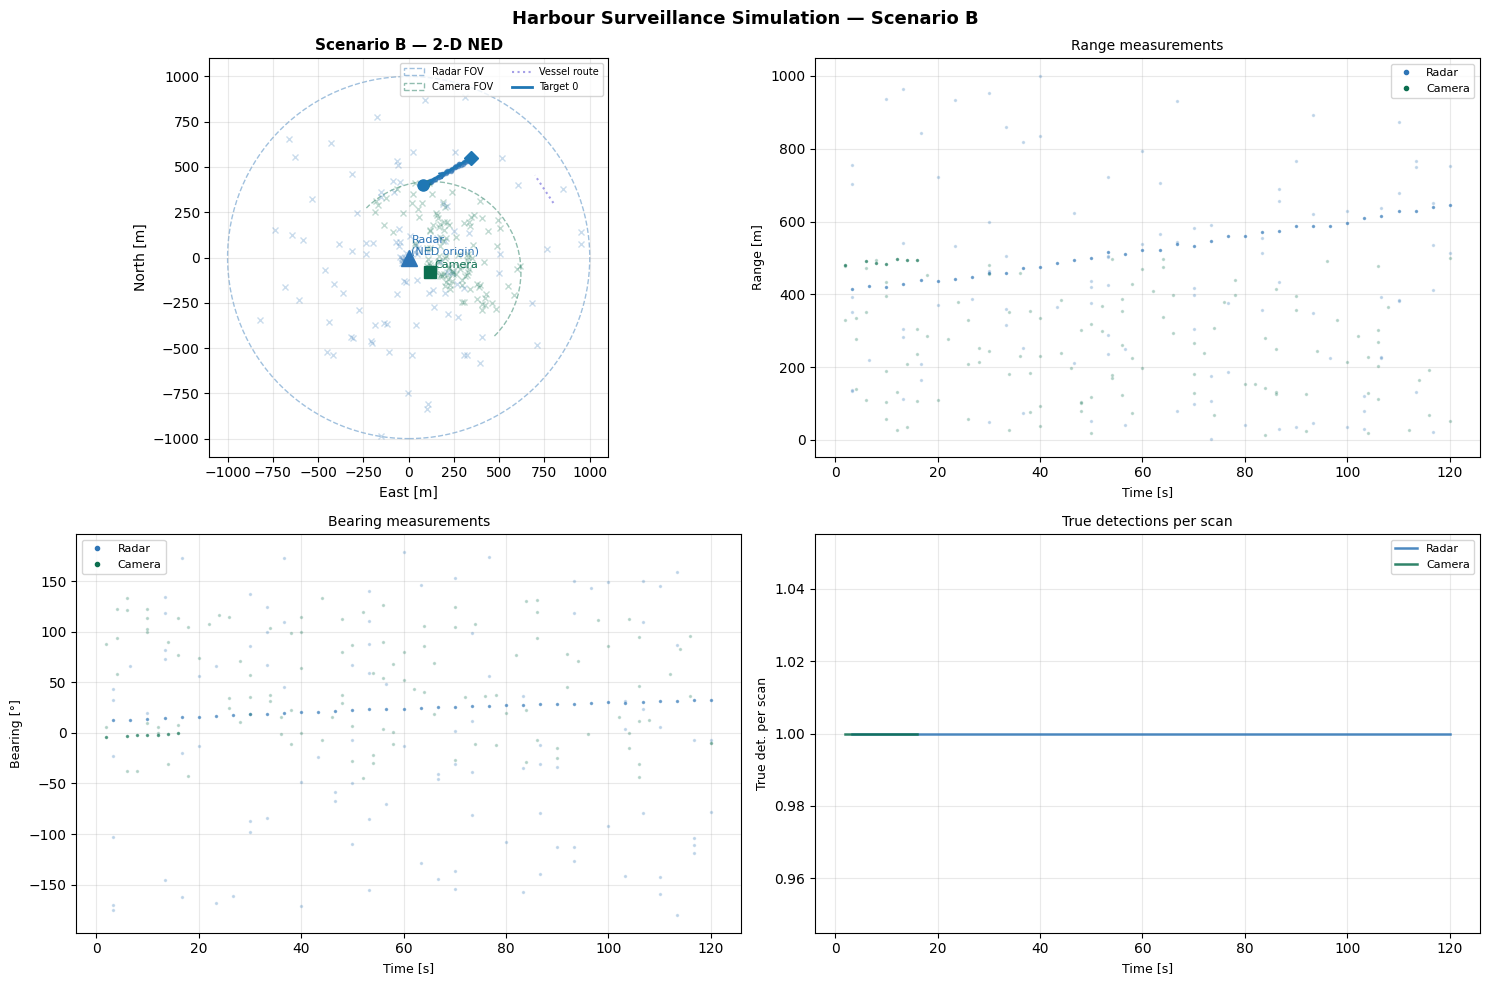

  Saved: harbour_sim_output\scenario_B.png
  Exported harbour_sim_output\scenario_B.json  (468.2 kB, 385 measurements)


'harbour_sim_output\\scenario_B.json'

In [11]:
#HAD TO EDIT THE DEFAULT AS IT USED INCORRET P_D VAL FRO RADAR AND CAMERA
#np.random.seed(42)
#sim_B = make_sim()

#targets_B = [
#    TargetConfig(
#        target_id=0,
#        initial_north=400.0, initial_east=80.0,
#        velocity_north=1.2, velocity_east=2.2,
#        has_ais=False,
#    )
#]

#output_B = sim_B.run(
#    targets        = targets_B,
#    t_end          = 120.0,
#    scenario_name  = "B",
#    active_sensors = ["radar", "camera", "gnss"],
#)

#modification:
np.random.seed(42)

r, c, a, g = make_sensors(
    radar_pd=0.90,
    radar_lfa=3.0,
    camera_pd=0.85,
    camera_lfa=2.0
)

v = VesselTrajectory(DEFAULT_PATROL, speed_knots=3.0)
sim_B = HarbourSimulation(r, c, a, g, v)

targets_B = [
    TargetConfig(
        target_id=0,
        initial_north=400.0,
        initial_east=80.0,
        velocity_north=1.2,
        velocity_east=2.2,
        has_ais=False,
    )
]

output_B = sim_B.run(
    targets=targets_B,
    t_end=120.0,
    scenario_name="B",
    active_sensors=["radar", "camera", "gnss"],
)


print_summary(output_B)
plot_scenario(output_B)
export_json(output_B)


---
## Scenario C — AIS-equipped target with sensor dropout

**Purpose**: validate asynchronous AIS fusion and demonstrate coasting
through a 30-second AIS blackout.  All sensors are active.
The AIS transponder is switched off between t = 60 s and t = 90 s.

**Success criteria**:
- Both tracks survive the AIS dropout (coasting on radar + camera).
- RMSE lower with AIS than without during the AIS-available windows.
- Track re-acquires AIS smoothly after t = 90 s.



══════════════════════════════════════════════════════════
  Scenario C     |  duration: 150.0 s  |  targets: 1
──────────────────────────────────────────────────────────
  Sensor       Total  True det.  False alarms
──────────────────────────────────────────────────────────
  radar          201         43           158
  camera         171         16           155
  ais             46         39             7
  gnss           150        150             0
══════════════════════════════════════════════════════════



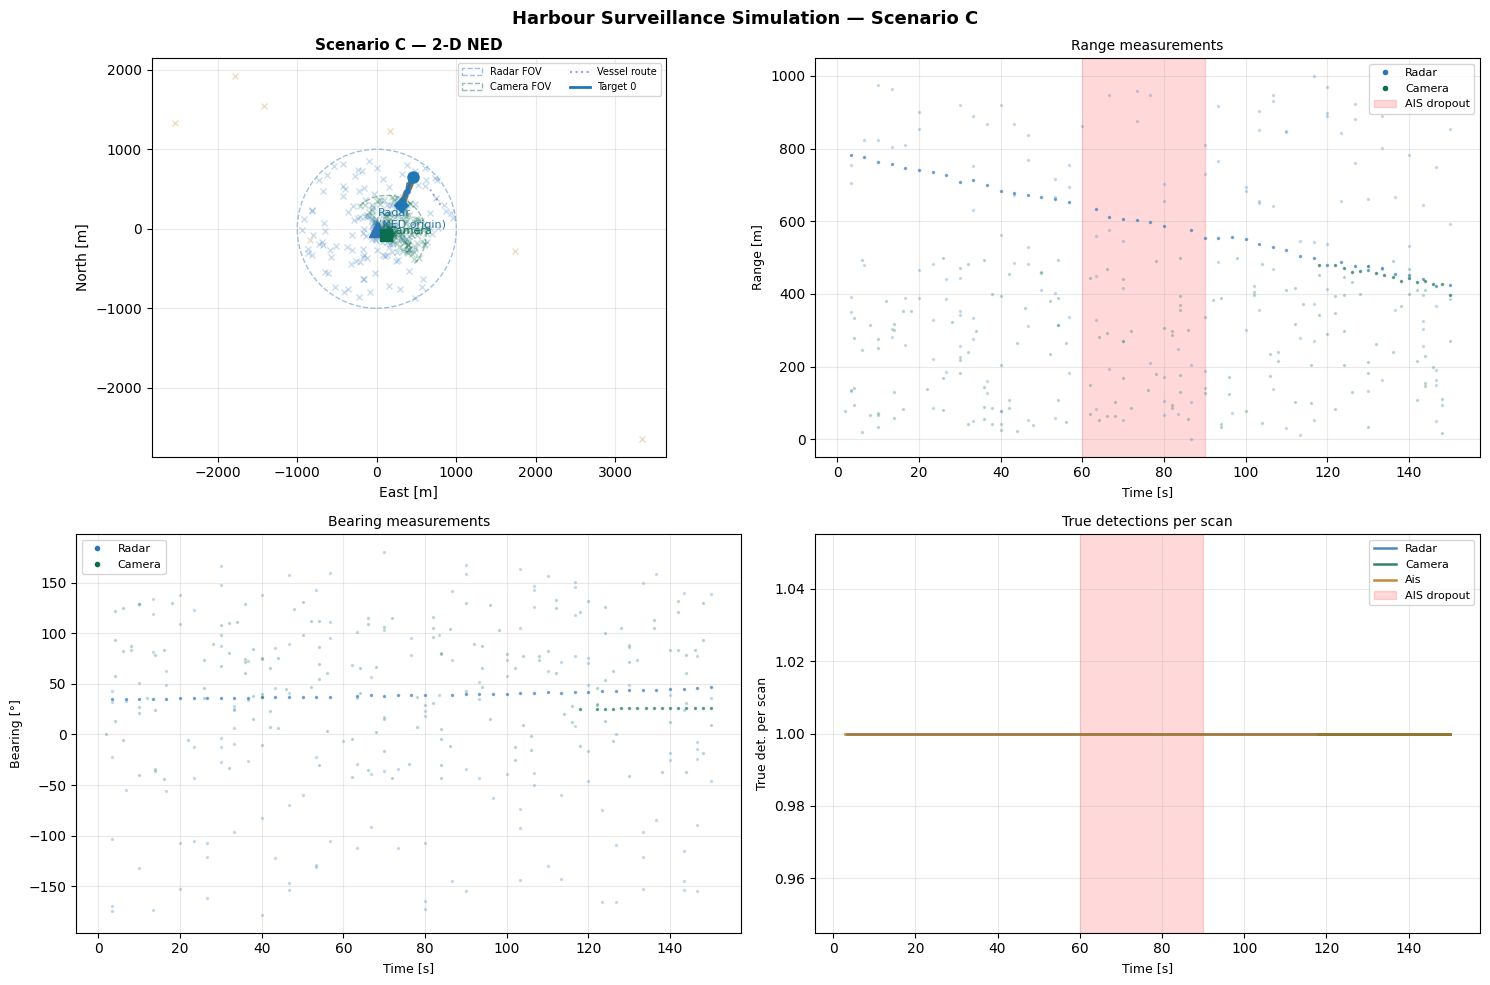

  Saved: harbour_sim_output\scenario_C.png
  Exported harbour_sim_output\scenario_C.json  (614.2 kB, 568 measurements)


'harbour_sim_output\\scenario_C.json'

In [12]:
np.random.seed(42)
AIS_DROPOUT_C = (60.0, 90.0)
sim_C = make_sim()

targets_C = [
    TargetConfig(
        target_id=0,
        initial_north=650.0, initial_east=450.0,
        velocity_north=-2.5, velocity_east=-1.0,
        has_ais=True,
    )
]

output_C = sim_C.run(
    targets        = targets_C,
    t_end          = 150.0,
    scenario_name  = "C",
    active_sensors = ["radar", "camera", "ais", "gnss"],
    ais_dropout    = AIS_DROPOUT_C,
)

print_summary(output_C)
plot_scenario(output_C, ais_dropout=AIS_DROPOUT_C)
export_json(output_C)


---
## Scenario D — Multiple targets, crossing trajectories

**Purpose**: validate Mahalanobis gating, GNN association under gate conflicts,
and track identity preservation through a crossing event.

Four targets are placed on converging headings that bring them within
≈ 30 m of each other near NED position (430, 310) between t ≈ 48 s and t ≈ 72 s.

**Success criteria**:
- All 4 tracks confirmed and maintained throughout.
- No identity swap at the crossing.
- OSPA < 40 m during and after the crossing.



══════════════════════════════════════════════════════════
  Scenario D     |  duration: 120.0 s  |  targets: 4
──────────────────────────────────────────────────────────
  Sensor       Total  True det.  False alarms
──────────────────────────────────────────────────────────
  radar          306        130           176
  camera         230         44           186
  ais              0          0             0
  gnss           120        120             0
══════════════════════════════════════════════════════════



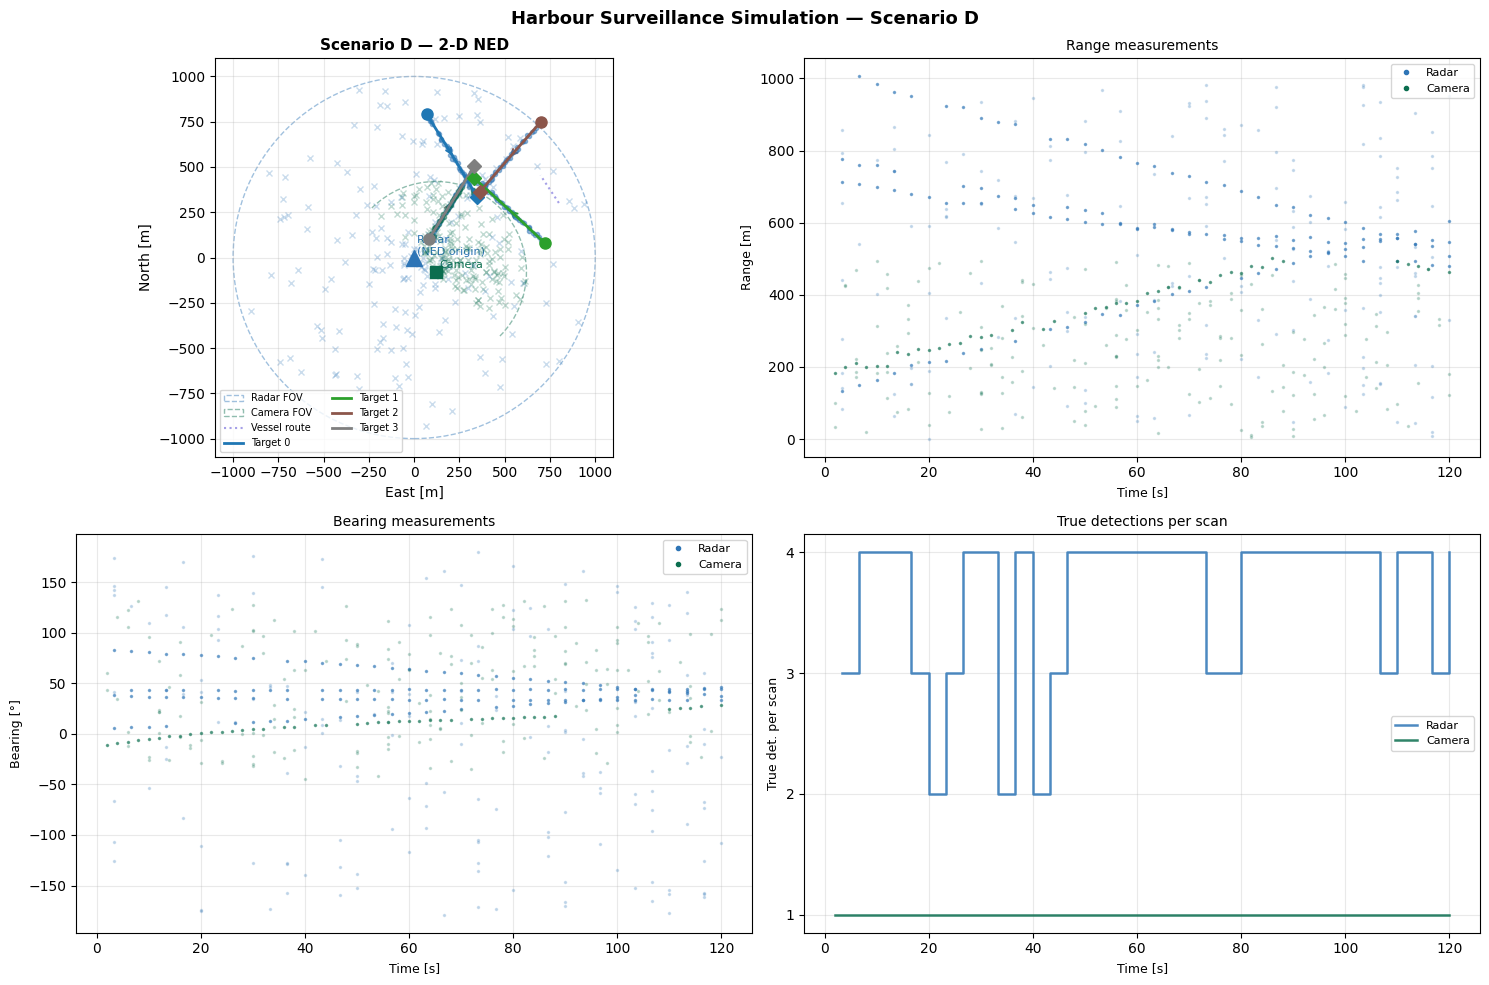

  Saved: harbour_sim_output\scenario_D.png
  Exported harbour_sim_output\scenario_D.json  (1666.9 kB, 656 measurements)


'harbour_sim_output\\scenario_D.json'

In [13]:
np.random.seed(42)
r_D, c_D, a_D, g_D = make_sensors(radar_pd=0.88, radar_lfa=5.0,
                                    camera_pd=0.88, camera_lfa=3.0)
v_D  = VesselTrajectory(DEFAULT_PATROL, speed_knots=3.0)
sim_D = HarbourSimulation(r_D, c_D, a_D, g_D, v_D)

# Targets designed to cross near (430, 310) at t ≈ 60 s
targets_D = [
    TargetConfig(target_id=0,
                 initial_north=790.0, initial_east=70.0,
                 velocity_north=-3.8, velocity_east=2.4),
    TargetConfig(target_id=1,
                 initial_north=80.0,  initial_east=720.0,
                 velocity_north=3.0,  velocity_east=-3.1),
    TargetConfig(target_id=2,
                 initial_north=750.0, initial_east=700.0,
                 velocity_north=-3.2, velocity_east=-2.8),
    TargetConfig(target_id=3,
                 initial_north=100.0, initial_east=80.0,
                 velocity_north=3.4,  velocity_east=2.1),
]

output_D = sim_D.run(
    targets        = targets_D,
    t_end          = 120.0,
    scenario_name  = "D",
    active_sensors = ["radar", "camera", "gnss"],
)

print_summary(output_D)
plot_scenario(output_D)
export_json(output_D)


---
## Scenario E — Mixed AIS / non-AIS harbour traffic

**Purpose**: validate the complete multi-target pipeline with realistic
harbour traffic: AIS-equipped commercial vessels and small craft without AIS,
targets entering and leaving the scene during the simulation.

**Configuration**:
- 3 AIS-equipped vessels (commercial traffic).
- 3 non-AIS small craft (invisible to AIS, radar + camera only).
- One AIS vessel enters at t = 30 s; one non-AIS vessel leaves at t = 100 s;
  one non-AIS vessel enters at t = 50 s.

**Success criteria**:
- All 6 targets tracked.
- Correct cardinality (track count) throughout.
- OSPA < 50 m throughout.



══════════════════════════════════════════════════════════
  Scenario E     |  duration: 180.0 s  |  targets: 6
──────────────────────────────────────────────────────────
  Sensor       Total  True det.  False alarms
──────────────────────────────────────────────────────────
  radar          593        251           342
  camera         417        159           258
  ais            180        170            10
  gnss           180        180             0
══════════════════════════════════════════════════════════



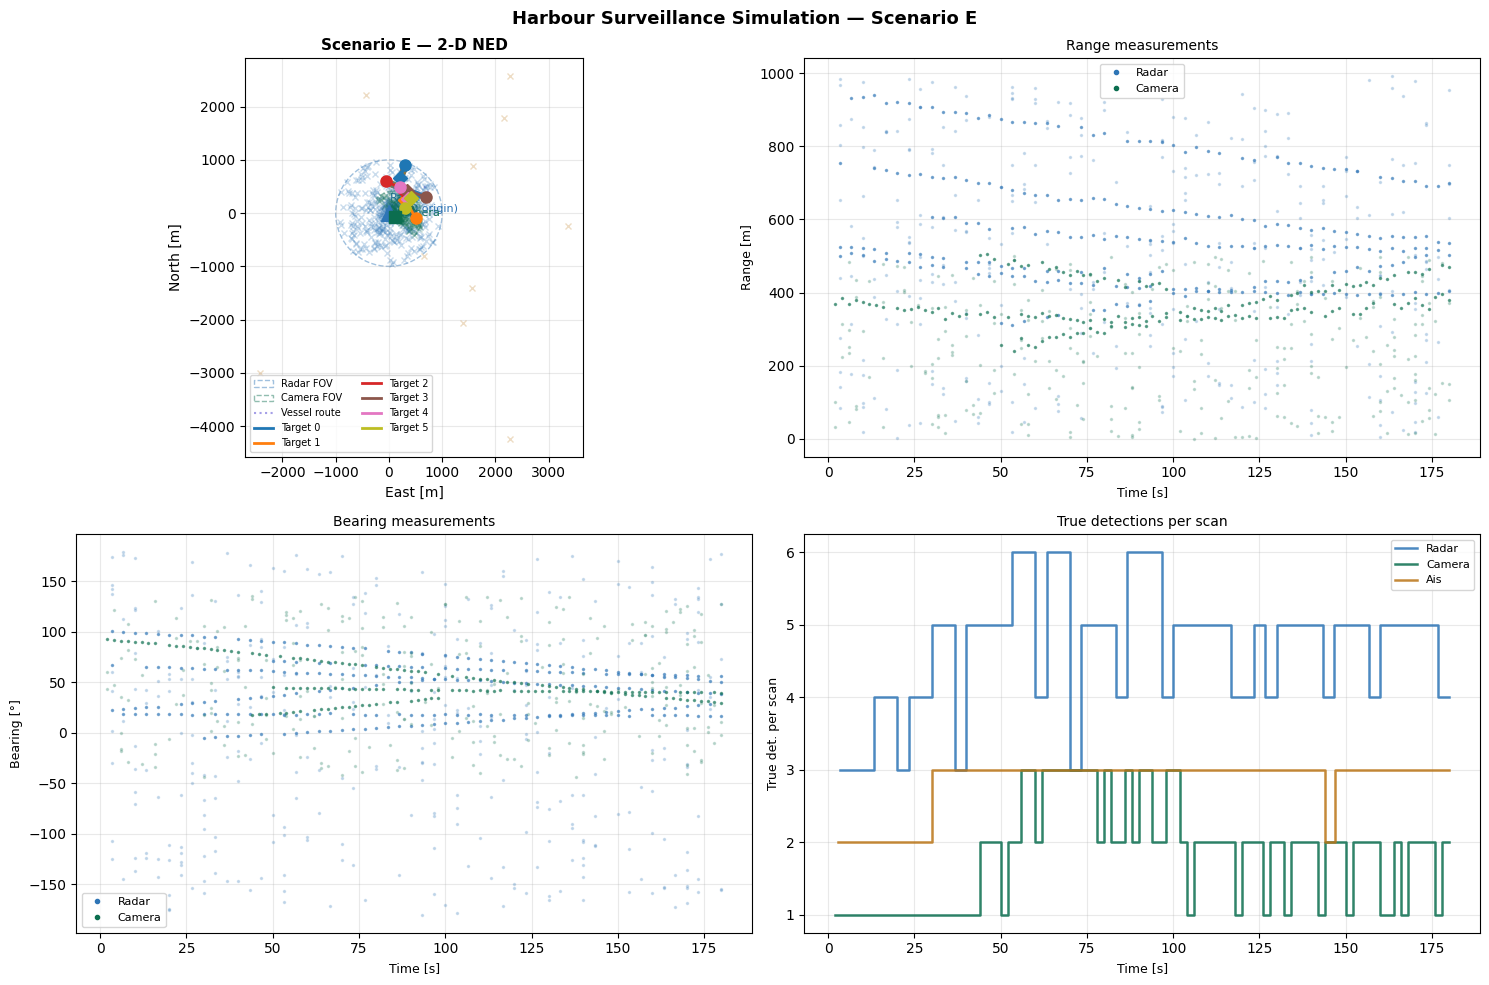

  Saved: harbour_sim_output\scenario_E.png
  Exported harbour_sim_output\scenario_E.json  (3223.4 kB, 1370 measurements)


'harbour_sim_output\\scenario_E.json'

In [14]:
np.random.seed(42)
r_E, c_E, a_E, g_E = make_sensors(radar_pd=0.90, radar_lfa=6.0,
                                    camera_pd=0.85, camera_lfa=3.0,
                                    ais_pd=0.98,    ais_lfa=0.2)
v_E  = VesselTrajectory(DEFAULT_PATROL, speed_knots=3.0)
sim_E = HarbourSimulation(r_E, c_E, a_E, g_E, v_E)

targets_E = [
    # ── AIS-equipped commercial vessels ─────────────────────────────────────
    TargetConfig(target_id=0,
                 initial_north=900.0, initial_east=300.0,
                 velocity_north=-1.5, velocity_east=-0.5,
                 has_ais=True),
    TargetConfig(target_id=1,
                 initial_north=-100.0, initial_east=500.0,
                 velocity_north=2.0,   velocity_east=-1.0,
                 has_ais=True),
    TargetConfig(target_id=2,
                 initial_north=600.0, initial_east=-50.0,
                 velocity_north=-1.0, velocity_east=2.0,
                 has_ais=True, active_from=30.0),   # enters at t=30 s
    # ── Non-AIS small craft ──────────────────────────────────────────────────
    TargetConfig(target_id=3,
                 initial_north=300.0, initial_east=700.0,
                 velocity_north=0.8,  velocity_east=-2.2,
                 has_ais=False),
    TargetConfig(target_id=4,
                 initial_north=500.0, initial_east=200.0,
                 velocity_north=-2.4, velocity_east=1.6,
                 has_ais=False, active_until=100.0),  # leaves at t=100 s
    TargetConfig(target_id=5,
                 initial_north=100.0, initial_east=300.0,
                 velocity_north=1.4,  velocity_east=0.9,
                 has_ais=False, active_from=50.0),    # enters at t=50 s
]

output_E = sim_E.run(
    targets        = targets_E,
    t_end          = 180.0,
    scenario_name  = "E",
    active_sensors = ["radar", "camera", "ais", "gnss"],
)

print_summary(output_E)
plot_scenario(output_E)
export_json(output_E)


---
## Section 9 — Load and inspect a saved scenario

The cell below demonstrates loading a previously exported JSON file
and inspecting its contents — the same interface the EKF tracker will use.


In [15]:
data = load_json(str(OUT_DIR / "scenario_D.json"))

print(f"Scenario      : {data['scenario_name']}")
print(f"Duration      : {data['t_end']} s")
print(f"Targets       : {list(data['ground_truth'].keys())}")
print(f"Measurements  : {len(data['measurements'])}")

# Show first 5 radar measurements
radar_meas = [m for m in data["measurements"] if m["sensor_id"] == "radar"]
print(f"\nFirst 5 radar measurements:")
for m in radar_meas[:5]:
    fa = " [FA]" if m["is_false_alarm"] else f" [tgt {m['target_id']}]"
    print(f"  t={m['time']:6.2f} s   r={m['range_m']:7.2f} m  "
          f"φ={np.rad2deg(m['bearing_rad']):7.2f}°{fa}")

# Show sensor configuration summary
print(f"\nSensor configurations:")
for sid, cfg in data["sensor_configs"].items():
    print(f"  {sid}: {cfg}")

print(f"\nAll output files in {OUT_DIR}/:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name:40s}  {f.stat().st_size/1024:6.1f} kB")


  Loaded  harbour_sim_output\scenario_D.json  (656 measurements)
Scenario      : D
Duration      : 120.0 s
Targets       : ['0', '1', '2', '3']
Measurements  : 656

First 5 radar measurements:
  t=  3.33 s   r= 776.37 m  φ=   5.73° [tgt 0]
  t=  3.33 s   r= 713.20 m  φ=  83.12° [tgt 1]
  t=  3.33 s   r= 132.11 m  φ=  38.06° [tgt 3]
  t=  3.33 s   r= 793.26 m  φ= -65.97° [FA]
  t=  3.33 s   r= 857.18 m  φ= 146.21° [FA]

Sensor configurations:
  radar: {'pos_ned': [0.0, 0.0], 'range_m': 1000.0, 'fov_deg': 360, 'rate_hz': 0.3, 'sigma_r_m': 5.0, 'sigma_phi_deg': 0.3, 'pd': 0.88, 'lambda_fa': 5.0}
  camera: {'pos_ned': [-80.0, 120.0], 'boresight_deg': 45.0, 'range_m': 500.0, 'fov_deg': 180, 'rate_hz': 0.5, 'sigma_r_m': 8.0, 'sigma_phi_deg': 0.15, 'pd': 0.88, 'lambda_fa': 3.0}
  ais: {'range_m': 5000.0, 'interval_s': 3.0, 'sigma_pos_m': 4.0, 'pd': 0.98}
  gnss: {'sigma_pos_m': 2.0, 'rate_hz': 1.0}

All output files in harbour_sim_output/:
  scenario_A.json                            448.4 kB

---
## Section 10 — Customisation guide for students

The simulation environment is fully configurable. Common customisations:

### Change sensor noise
```python
radar = RadarSensor(sigma_r=10.0, sigma_phi=np.deg2rad(0.5), ...)
```

### Add a target manoeuvre (coordinated turn approximation)
```python
# Add a velocity kick at a specific time step inside the simulation loop
# (subclass HarbourSimulation and override the propagation step)
```

### Disable a sensor
```python
output = sim.run(..., active_sensors=["radar", "gnss"])  # camera + AIS off
```

### Adjust false alarm density
```python
radar = RadarSensor(lambda_fa=8.0)  # denser clutter
```

### Change vessel speed
```python
vessel = VesselTrajectory(DEFAULT_PATROL, speed_knots=5.0)
```

### Reproduce exactly (fix random seed)
```python
np.random.seed(123)
output = sim.run(...)
```

### Extend to a coordinated-turn target
Replace the CV propagation in `HarbourSimulation.run()` with:
```python
# CT update (linearised, for small dt)
psi = np.arctan2(states[tid][3], states[tid][2])  # current heading
omega = 3.0 * np.pi / 180   # 3°/s turn rate
v     = np.linalg.norm(states[tid][2:4])
states[tid][0] += v * np.cos(psi) * dt
states[tid][1] += v * np.sin(psi) * dt
states[tid][2]  = v * np.cos(psi + omega * dt)
states[tid][3]  = v * np.sin(psi + omega * dt)
```


<br>
<br>

## Section 11 — Coordinate Frame Manager

Below, the coordinate frame manager is defined. Its main objectives are:

- Store the known NED-frame offset of the stereo camera relative to the NED origin (mm-wave radar position). The radar itself has zero offset.
- Accept GNSS fixes from the vessel and maintain a running estimate of the vessel NED position v(t), used as the effective position offset for AIS measurements.
- Compute $h_i(x,t)$ and $H_i(x,t)$ for each sensor 'i' and target 'x'
- Provide the measurement noise covariance $R_i$ for each sensor (main source: sensor specifications' table)

Additionally, provided a test on the implemented module to confirm:

&nbsp; &nbsp; &nbsp; a) A known NED-frame target position generates the expected (range, bearing) for each sensor

&nbsp; &nbsp; &nbsp; b) The measurement function produces the expected output for a known input

&nbsp; &nbsp; &nbsp; c) The AIS position-to-observation conversion is consistent with the radar measurement at the same target location

In [16]:
class CoordinateFrameManager:
    """
    Coordinate Frame Manager that strictly computes h(x, t) and H_i 
    based on the specific sensor configuration table.
    """
    def __init__(self, sensor, sensor_id: str):
        self.sensor_id = sensor_id
        self.sensor = sensor

        if sensor_id == "camera":
            self.ned = sensor.pos_ned


    def _get_origin(self, vessel_pos: Optional[np.ndarray]) -> np.ndarray:
        # AIS uses dynamic vessel position; others use their own fixed NED position
        if self.sensor_id == 'ais':
            return vessel_pos if vessel_pos is not None else np.array([0.0, 0.0])
        
        # Access position attribute from the specific sensor instance
        if hasattr(self.sensor, 'pos_ned'):
            return np.array(self.sensor.pos_ned)
        return np.array([0.0, 0.0])
    

    def get_h(self, x: np.ndarray, vessel_pos: Optional[np.ndarray] = None) -> np.ndarray:
        p = x[:2]
        if self.sensor_id in ['ais', 'gnss']:
            return p
        
        s = self._get_origin(vessel_pos)
        diff = p - s
        r = np.linalg.norm(diff)
        phi = np.arctan2(diff[1], diff[0])
        return np.array([r, phi])
    

    def get_H(self, x: np.ndarray, vessel_pos: Optional[np.ndarray] = None) -> np.ndarray:
        if self.sensor_id in ['ais', 'gnss']:
            # Identity mapping for position [N, E]
            H = np.zeros((2, 4))
            H[0, 0] = 1.0
            H[1, 1] = 1.0
            return H
            
        s = self._get_origin(vessel_pos)
        diff = x[:2] - s
        r2 = np.sum(diff**2)
        r = np.sqrt(r2)
        if r < 1e-6: return np.zeros((2, 4))
        
        return np.array([
            [diff[0]/r, diff[1]/r, 0, 0],
            [-diff[1]/r2, diff[0]/r2, 0, 0]
        ])
    

    def get_R(self) -> np.ndarray:
        specs = {
            'radar':  {'sigma_r': 5.0, 'sigma_phi': np.deg2rad(0.3)},
            'camera': {'sigma_r': 8.0, 'sigma_phi': np.deg2rad(0.15)},
            'ais':    {'sigma_pos': 4.0},
            'gnss':   {'sigma_pos': 2.0}
        }
        spec = specs[self.sensor_id]
        if self.sensor_id in ['radar', 'camera']:
            return np.diag([spec['sigma_r']**2, spec['sigma_phi']**2])
        return np.diag([spec['sigma_pos']**2, spec['sigma_pos']**2])


# ── Verification Unit Tests ──────────────────────────────────────────────────
def run_validation():
    # Setup instances
    radar = RadarSensor()
    cam = StereoCameraSensor()
    ais = AISSensor()
    gnss = GNSSSensor()
    
    target_x = np.array([300.0, 400.0, 0.0, 0.0])
    vessel_pos = np.array([10.0, 10.0])

    # (a) Verify known target position generates expected (range, bearing) for radar/camera
    cfm_r = CoordinateFrameManager(radar, 'radar')
    h_radar = cfm_r.get_h(target_x)
    assert np.isclose(h_radar[0], np.sqrt(300.0**2 + 400.0**2)) and np.isclose(h_radar[1], np.arctan2(400, 300))
    
    cfm_c = CoordinateFrameManager(cam, 'camera')
    h_cam = cfm_c.get_h(target_x)
    assert np.isclose(h_cam[0], np.linalg.norm(target_x[:2] - cam.pos_ned))

    # (b) Verify h(x) produces expected output for ALL sensors

    # Check match between (N,E) positions (GNSS and AIS)
    assert np.allclose(CoordinateFrameManager(gnss, 'gnss').get_h(target_x), target_x[:2])
    assert np.allclose(CoordinateFrameManager(ais, 'ais').get_h(target_x, vessel_pos), target_x[:2])

    # For range-bearing sensors, check that the output is a 2-element vector (r, phi)
    h_rad = CoordinateFrameManager(radar, 'radar').get_h(target_x)
    assert len(h_rad) == 2
    assert h_rad[0] > 0
    assert -np.pi <= h_rad[1] <= np.pi

    h_rad = CoordinateFrameManager(cam, 'camera').get_h(target_x)
    assert len(h_rad) == 2
    assert h_rad[0] > 0
    assert -np.pi <= h_rad[1] <= np.pi

    # (c) Verify AIS consistency with Radar
    ais_obs_ned = CoordinateFrameManager(ais, 'ais').get_h(target_x, vessel_pos=np.array([0.0, 0.0]))
    r_conv = np.linalg.norm(ais_obs_ned)
    phi_conv = np.arctan2(ais_obs_ned[1], ais_obs_ned[0])
    assert np.isclose(r_conv, h_radar[0]) and np.isclose(phi_conv, h_radar[1])

    print("All validation tests passed successfully.")

run_validation()

All validation tests passed successfully.


Section 12: EKF

In [17]:
class EKF:

    def __init__(self, X, P, sigma_a):
        self.X = np.asarray(X, dtype=float)
        self.P = np.asarray(P, dtype=float)
        self.sigma_a = sigma_a


    def predict(self, dt):

        #cv model object call:
        motion_model = CVMotionModel(dt=dt, sigma_a=self.sigma_a)
        F = motion_model.F
        Q = motion_model.Q

        #use CV model (which is already linear) for propogation
        self.X = F @ self.X

        #Prediction
        self.P = F @ self.P @ F.T + Q

        return self.X, self.P

    #for sequential update the update dunction is generic as the z,h,H,R terms come from outside class
    #from JSON file and frame manger
    def update(self, z, h, H, R, wrap_bearing=False):
        """
        :param z: actual measumrent from json
        :param h: predicted measurment from current ekf state
        :param H: measumrent jacobian from coord manger
        :param R: radar measurment noise from coord manager
        :return:
        """

        #make everything as np.array with float type
        z = np.asarray(z, dtype=float)
        h = np.asarray(h, dtype=float)
        H = np.asarray(H, dtype=float)
        R = np.asarray(R, dtype=float)

        #compute innovation
        y = z - h
        #wrap innovation bearing
        if wrap_bearing:
            y[1] = wrap_angle(y[1])


        #innovation covariance
        S = H @ self.P @ H.T + R

        #kalman gain
        K = self.P @ H.T @ np.linalg.inv(S)

        #state update
        self.X = self.X + K @ y

        #covariance update (joseph eq for numerical stability)
        I = np.eye(len(self.X))
        IKH = I - K @ H
        self.P = IKH @ self.P @ IKH.T + K @ R @ K.T

        return self.X, self.P, y, S

    #update step for joint update (since radar and camera update at same rate)
    #specific to radar camera sensors
    def cam_radar_update_joint(self, z_radar, z_cam, h_radar, h_cam, H_radar, H_cam, R_radar, R_cam):
        """
        :param z_radar: actual radar measurements [range,bearing]
        :param z_cam: actual cam measurement [range,bearing] at offset handles internally by frame manger
        :param h_radar: predicted radar measurements [range,bearing]
        :param h_cam: predicted cam measurements [range,bearing]
        :param H_radar: observation jacobian for radar [2x4]
        :param H_cam: observation jacobian for camera [2x4]
        :param R_Radar: measurement noise for radar [2x2]
        :param R_cam: measurement noise for camera [2x2]
        :return:
        """
        from scipy.linalg import block_diag


        #make everything as np.array with float type
        z_radar = np.asarray(z_radar, dtype=float)
        h_radar = np.asarray(h_radar, dtype=float)
        H_radar = np.asarray(H_radar, dtype=float)
        R_radar = np.asarray(R_radar, dtype=float)

        z_cam = np.asarray(z_cam, dtype=float)
        h_cam = np.asarray(h_cam, dtype=float)
        H_cam = np.asarray(H_cam, dtype=float)
        R_cam = np.asarray(R_cam, dtype=float)

        #create joint vectors and matrixes (stack vertcially)
        z_joint = np.concatenate((z_radar, z_cam)) #this should provide a vector (4,)
        h_joint = np.concatenate((h_radar, h_cam)) #this should provide a vector (4,)
        H_joint = np.vstack((H_radar, H_cam)) #this can be stacked with vstack [4x4]
        R_joint = block_diag(R_radar, R_cam) #R terms go along diagonal so we stack with block diag [4x4]

        #compute innovation
        y = z_joint - h_joint
        #wrap angle of cam and radar bearing
        y[1] = wrap_angle(y[1])
        y[3] = wrap_angle(y[3])


        #innovation covariance
        S = H_joint @ self.P @ H_joint.T + R_joint

        #kalman gain
        K = self.P @ H_joint.T @ np.linalg.inv(S)

        #state update
        self.X = self.X + K @ y

        #covariance update (joseph eq for numerical stability)
        I = np.eye(len(self.X))
        IKH = I - K @ H_joint
        self.P = IKH @ self.P @ IKH.T + K @ R_joint @ K.T

        return self.X, self.P, y, S

    def compute_innovation(self, z, h, H, R):
        """
        Computes the innovation and innovation covariance without updating the state.
        This is required by the Data Association module for gating.
        """
        z = np.asarray(z, dtype=float)
        h = np.asarray(h, dtype=float)
        H = np.asarray(H, dtype=float)
        R = np.asarray(R, dtype=float)

        # Compute innovation
        y = z - h

        # Wrap innovation bearing
        y[1] = wrap_angle(y[1])

        # Innovation covariance
        S = H @ self.P @ H.T + R

        return y, S

SCENARIO A: VALIDATION

  Loaded  harbour_sim_output/scenario_A.json  (263 measurements)

--- Global RMSE Performance ---
Position RMSE: 4.05 m
RMSE requirement passed: True

--- NIS Performance ---
NIS inside 95% bounds: 100.0%
NIS requirement passed: True


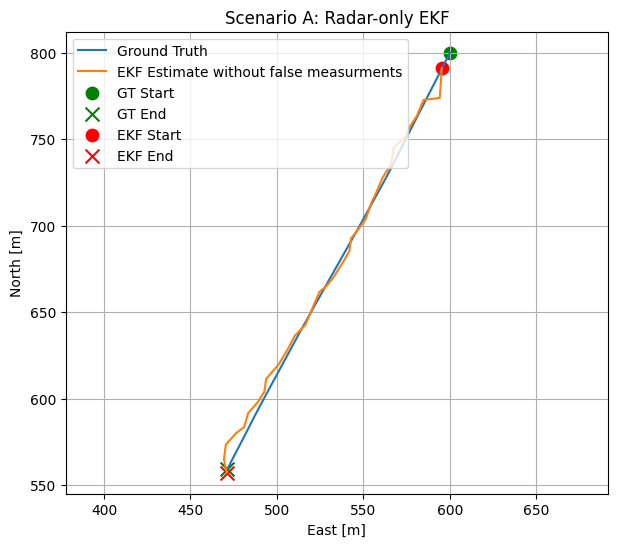

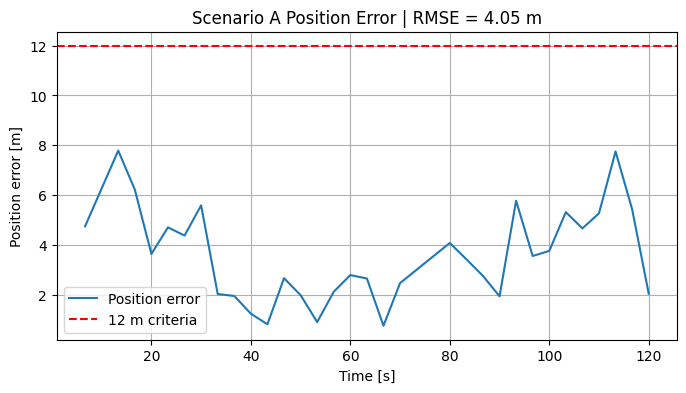

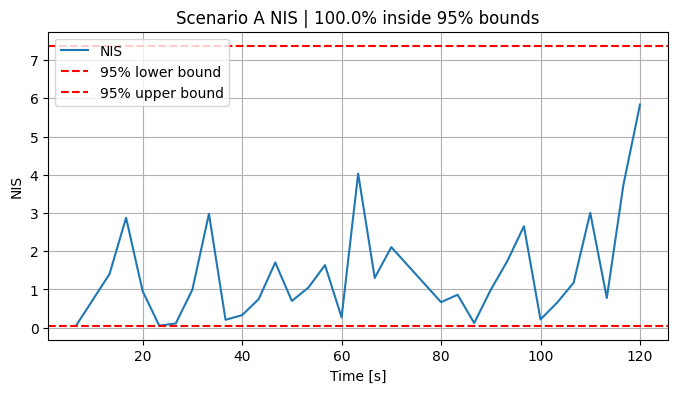

All radar: 143
True radar: 33
False alarms: 110


In [24]:
#SCENARIO A: VALLIDATION


# 1. Load Scenario A
data = load_json("harbour_sim_output/scenario_A.json")

# 2. Ground truth for target 0
gt_rows = np.array(data["ground_truth"]["0"])
gt_times = gt_rows[:, 0]
gt_states = gt_rows[:, 1:5]   # [p_N, p_E, v_N, v_E]

# 3. Radar measurements only
#we exclude false measumrents so we can test ekf correctly later with NIS
#as NIS is used for ensuring correct tuning of P and Q if we iclude false we may get bad result
#even if correctly tuned (false measurment are for the MTT with gating to filter them)
radar_measurements = [
    m for m in data["measurements"]
    if m["sensor_id"] == "radar" and not m["is_false_alarm"]
]

radar_measurements = sorted(radar_measurements, key=lambda m: m["time"]) #sort in order fo time

# 4. Apply EKF:
m0 = radar_measurements[0] #extrcat initial measrements

r0 = m0["range_m"]  #extrcat the range
b0 = m0["bearing_rad"] #extrcat the bearing

pN0 = r0 * np.cos(b0) #convert to north postion [m]
pE0 = r0 * np.sin(b0) #convert to east position [m]

X0 = np.array([pN0, pE0, 0.0, 0.0]) #initial state
P0 = np.diag([100.0, 100.0, 25.0, 25.0]) #initial covaraince (set high since we dont knowwhere target is)

#create ekf object
ekf = EKF(X0, P0, sigma_a=0.05) #sigma_a default of 0.05 from script

#frame maneger object
radar = RadarSensor()
cfm_radar = CoordinateFrameManager(radar, "radar")

#initilize empty list to store ekf estimates, times, NIS values
state_estimates = []
times = []
NIS_values = []

#loop
last_t = radar_measurements[0]["time"] #initial time
for m in radar_measurements[1:]:

    #compute dt based on current time and last time
    time = m["time"]
    dt = time - last_t

    #predict
    ekf.predict(dt=dt)

    #get actual measurments from sensor
    z_radar = np.array([m["range_m"], m["bearing_rad"]])

    #use coord frame manager to get h,H,R
    h_radar = cfm_radar.get_h(ekf.X) #[range,bearing]
    H_radar = cfm_radar.get_H(ekf.X) #[2x4]
    R_radar = cfm_radar.get_R() #[2x2]

    #update (for wave radar)
    X, P, y, S = ekf.update(z=z_radar, h=h_radar, H=H_radar, R=R_radar)

    #compute NIS
    NIS = y @ np.linalg.inv(S) @ y.T

    #store values
    state_estimates.append(X.copy())
    times.append(time)
    NIS_values.append(NIS)

    #propogate time (X, P handeled internally by class)
    last_t = time

#covnert lists to arrays
state_estimates_arr = np.array(state_estimates)
times_arr = np.array(times)
NIS_values_arr = np.array(NIS_values)

#compute position RMSE
from scipy.stats import chi2

# Match ground truth position to EKF estimate times
gt_pos_matched = []

#mathc the times
for t in times_arr:
    idx = np.argmin(np.abs(gt_times - t)) #idx for min when times between gt and ekf match
    gt_pos_matched.append(gt_states[idx, 0:2]) #for matched index store the range and bearing

gt_pos_matched = np.array(gt_pos_matched) #convert to array

# Position error over time
pos_errors = state_estimates_arr[:, 0:2] - gt_pos_matched
pos_error_norm = np.linalg.norm(pos_errors, axis=1)

# Overall position RMSE
position_rmse = np.sqrt(np.mean(pos_error_norm**2))

#pritn and valdiate position rmse below 12m
print(f"\n--- Global RMSE Performance ---")
print(f"Position RMSE: {position_rmse:.2f} m")
print("RMSE requirement passed:", position_rmse < 12.0)

#NIS validation:
lower = chi2.ppf(0.025, df=2)
upper = chi2.ppf(0.975, df=2)

inside = (NIS_values_arr >= lower) & (NIS_values_arr <= upper)
percent_inside = 100 * np.mean(inside)

print(f"\n--- NIS Performance ---")
print(f"NIS inside 95% bounds: {percent_inside:.1f}%")
print("NIS requirement passed:", percent_inside > 90.0)

#plot the results:
#GROUND TRUTH PLOT AGAINGST STATE ESTIMATE
plt.figure(figsize=(7,6))
plt.plot(gt_states[:,1], gt_states[:,0], label="Ground Truth")
plt.plot(state_estimates_arr[:,1], state_estimates_arr[:,0], label="EKF Estimate without false measurments")


# --- Ground truth start/end ---
plt.scatter(gt_states[0,1], gt_states[0,0], c='green', s=80, label="GT Start")
plt.scatter(gt_states[-1,1], gt_states[-1,0], c='green', marker='x', s=100, label="GT End")

# --- EKF start/end ---
plt.scatter(state_estimates_arr[0,1], state_estimates_arr[0,0], c='red', s=80, label="EKF Start")
plt.scatter(state_estimates_arr[-1,1], state_estimates_arr[-1,0], c='red', marker='x', s=100, label="EKF End")

plt.xlabel("East [m]")
plt.ylabel("North [m]")
plt.title("Scenario A: Radar-only EKF")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

#POSITION RMSE PLOT:
plt.figure(figsize=(8,4))
plt.plot(times_arr, pos_error_norm, label="Position error")
plt.axhline(12.0, color='r', linestyle="--", label="12 m criteria")
plt.xlabel("Time [s]")
plt.ylabel("Position error [m]")
plt.title(f"Scenario A Position Error | RMSE = {position_rmse:.2f} m")
plt.grid(True)
plt.legend()
plt.show()

#NIS PLOT
plt.figure(figsize=(8,4))
plt.plot(times_arr, NIS_values_arr, label="NIS")
plt.axhline(lower, color='r', linestyle="--", label="95% lower bound")
plt.axhline(upper, color='r', linestyle="--", label="95% upper bound")
plt.xlabel("Time [s]")
plt.ylabel("NIS")
plt.title(f"Scenario A NIS | {percent_inside:.1f}% inside 95% bounds")
plt.grid(True)
plt.legend()
plt.show()

#stress test to show true measurments vs false measurments vs total meaurments
all_radar = [m for m in data["measurements"] if m["sensor_id"] == "radar"]
print("All radar:", len(all_radar))
print("True radar:", len(radar_measurements))
print("False alarms:", len(all_radar) - len(radar_measurements))

SCENARIO B VALIDATION

  Loaded  harbour_sim_output/scenario_B.json  (385 measurements)

--- Global RMSE Performance ---
Position RMSE: 3.40 m
RMSE requirement passed: True

--- NIS Performance ---
NIS inside 95% bounds: 95.3%
NIS requirement passed: True


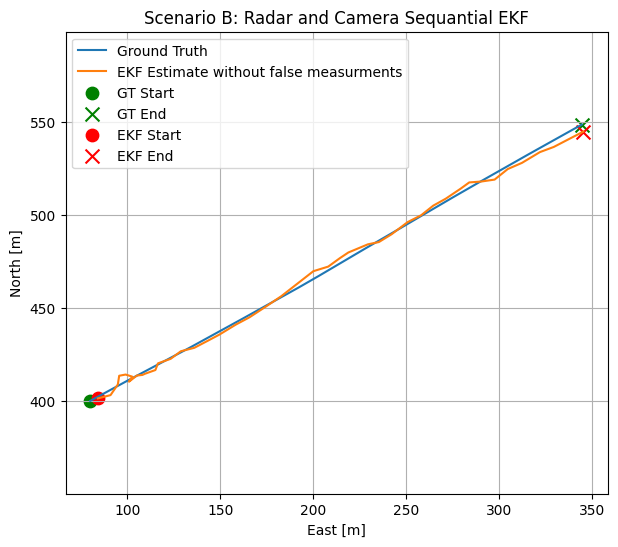

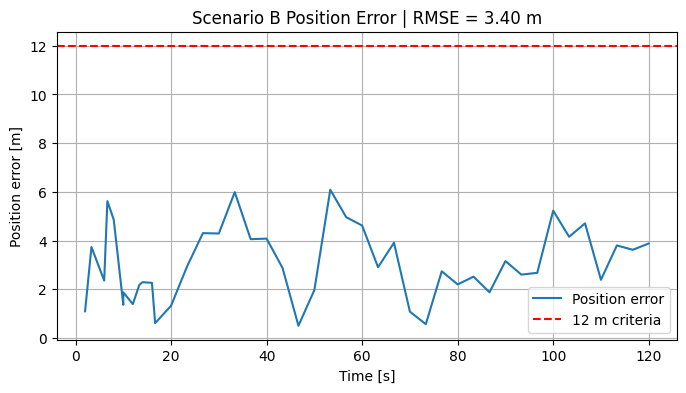

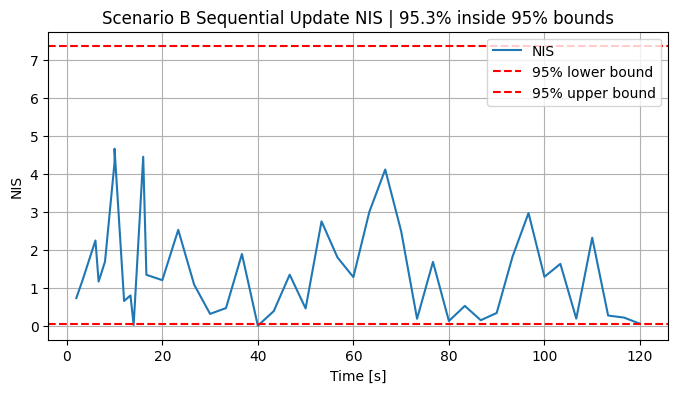

In [23]:
###  SCENARIO B: SQUENTIAL UPDATE VERSION

# 1. Load Scenario B
data_B = load_json("harbour_sim_output/scenario_B.json")
#print(data_B["sensor_configs"]) #debug to check if scenrio param was coorect

# 2. Ground truth for target 0
gt_rows = np.array(data_B["ground_truth"]["0"])
gt_times = gt_rows[:, 0]
gt_states = gt_rows[:, 1:5]   # [p_N, p_E, v_N, v_E]

#Radar and camera measurment combined for mian ekf loop
measurements_B = [
    m for m in data_B["measurements"]
    if m["sensor_id"] in ["radar", "camera"] and not m["is_false_alarm"]
]

# Refined sorting to ensure Radar is processed before Camera if timestamps are identical
#sort in order of time since we have sensor ids, we can leverage that to update sequentily rather
# than using timestamp matching
measurements_B = sorted(measurements_B, key=lambda m: (m["time"], 0 if m["sensor_id"] == "radar" else 1))



#extrcating radar only for ekf initilization
radar_measurements = [
    m for m in data_B["measurements"]
    if m["sensor_id"] == "radar" and not m["is_false_alarm"]
]

radar_measurements = sorted(radar_measurements, key=lambda m: m["time"])

#initilize ekf (use radar since its setup around 0,0)
m0 = radar_measurements[0] #extrcat initial measrements

r0 = m0["range_m"]  #extrcat the range
b0 = m0["bearing_rad"] #extrcat the bearing

pN0 = r0 * np.cos(b0) #convert to north postion [m]
pE0 = r0 * np.sin(b0) #convert to east position [m]

X0 = np.array([pN0, pE0, 0.0, 0.0]) #initial state
P0 = np.diag([100.0, 100.0, 25.0, 25.0]) #initial covaraince (set high since we dont knowwhere target is)

#create ekf object
ekf = EKF(X0, P0, sigma_a=0.05)

#frame manager
radar = RadarSensor()
camera = StereoCameraSensor()
cfm_radar = CoordinateFrameManager(radar, "radar")
cfm_camera = CoordinateFrameManager(camera, "camera")

#initilize empty list to store ekf estimates, times, NIS values
state_estimates = []
times = []
NIS_values = []

#loop
last_t = measurements_B[0]["time"] #initial time
for m in measurements_B:

    #dt calc for propogation
    time = m["time"]
    dt = time - last_t

    #predict
    ekf.predict(dt=dt)

    #check what sensor id current measurment has at timestep
    #since we ordered timestamp in order of time and we have index based ons sensor id
    #after predict we check id get data for update then update
    #if both at same time stamp we will update based on order (sequentilly)
    if m["sensor_id"] == "radar":
        z = np.array([m["range_m"], m["bearing_rad"]])

        #use coord frame manager
        h = cfm_radar.get_h(ekf.X)
        H = cfm_radar.get_H(ekf.X)
        R = cfm_radar.get_R()

    else:
        z = np.array([m["range_m"], m["bearing_rad"]])

        #use coord frame manager
        h = cfm_camera.get_h(ekf.X)
        H = cfm_camera.get_H(ekf.X)
        R = cfm_camera.get_R()

    X, P, y, S = ekf.update(z=z, h=h, H=H, R=R)

    #compute NIS
    NIS = y @ np.linalg.inv(S) @ y.T

    #store values
    state_estimates.append(X.copy())
    times.append(time)
    NIS_values.append(NIS)

    #propogate time (X, P handeled internally by class)
    last_t = time

#covnert lists to arrays
state_estimates_arr = np.array(state_estimates)
times_arr = np.array(times)
NIS_values_arr = np.array(NIS_values)

#POSTION RMSE
# Match ground truth position to EKF estimate times
gt_pos_matched = []

#mathc the times
for t in times_arr:
    idx = np.argmin(np.abs(gt_times - t)) #idx for min when times between gt and ekf match
    gt_pos_matched.append(gt_states[idx, 0:2]) #for matched index store the range and bearing

gt_pos_matched = np.array(gt_pos_matched) #convert to array

# Position error over time
pos_errors = state_estimates_arr[:, 0:2] - gt_pos_matched
pos_error_norm = np.linalg.norm(pos_errors, axis=1)

# Overall position RMSE
position_rmse = np.sqrt(np.mean(pos_error_norm**2))

#pritn and valdiate position rmse below 12m
print(f"\n--- Global RMSE Performance ---")
print(f"Position RMSE: {position_rmse:.2f} m")
print("RMSE requirement passed:", position_rmse < 12.0)

#NIS validation:
lower = chi2.ppf(0.025, df=2)
upper = chi2.ppf(0.975, df=2)

inside = (NIS_values_arr >= lower) & (NIS_values_arr <= upper)
percent_inside = 100 * np.mean(inside)

print(f"\n--- NIS Performance ---")
print(f"NIS inside 95% bounds: {percent_inside:.1f}%")
print("NIS requirement passed:", percent_inside > 90.0)

#plot the results:
#GROUND TRUTH PLOT AGAINGST STATE ESTIMATE
plt.figure(figsize=(7,6))
plt.plot(gt_states[:,1], gt_states[:,0], label="Ground Truth")
plt.plot(state_estimates_arr[:,1], state_estimates_arr[:,0], label="EKF Estimate without false measurments")


# --- Ground truth start/end ---
plt.scatter(gt_states[0,1], gt_states[0,0], c='green', s=80, label="GT Start")
plt.scatter(gt_states[-1,1], gt_states[-1,0], c='green', marker='x', s=100, label="GT End")

# --- EKF start/end ---
plt.scatter(state_estimates_arr[0,1], state_estimates_arr[0,0], c='red', s=80, label="EKF Start")
plt.scatter(state_estimates_arr[-1,1], state_estimates_arr[-1,0], c='red', marker='x', s=100, label="EKF End")

plt.xlabel("East [m]")
plt.ylabel("North [m]")
plt.title("Scenario B: Radar and Camera Sequantial EKF")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

#POSITION RMSE PLOT:
plt.figure(figsize=(8,4))
plt.plot(times_arr, pos_error_norm, label="Position error")
plt.axhline(12.0, color='r', linestyle="--", label="12 m criteria")
plt.xlabel("Time [s]")
plt.ylabel("Position error [m]")
plt.title(f"Scenario B Position Error | RMSE = {position_rmse:.2f} m")
plt.grid(True)
plt.legend()
plt.show()

#NIS PLOT
plt.figure(figsize=(8,4))
plt.plot(times_arr, NIS_values_arr, label="NIS")
plt.axhline(lower, color='r', linestyle="--", label="95% lower bound")
plt.axhline(upper, color='r', linestyle="--", label="95% upper bound")
plt.xlabel("Time [s]")
plt.ylabel("NIS")
plt.title(f"Scenario B Sequential Update NIS | {percent_inside:.1f}% inside 95% bounds")
plt.grid(True)
plt.legend()
plt.show()



  Loaded  harbour_sim_output/scenario_B.json  (385 measurements)
Position RMSE: 3.43 m
RMSE requirement passed: True


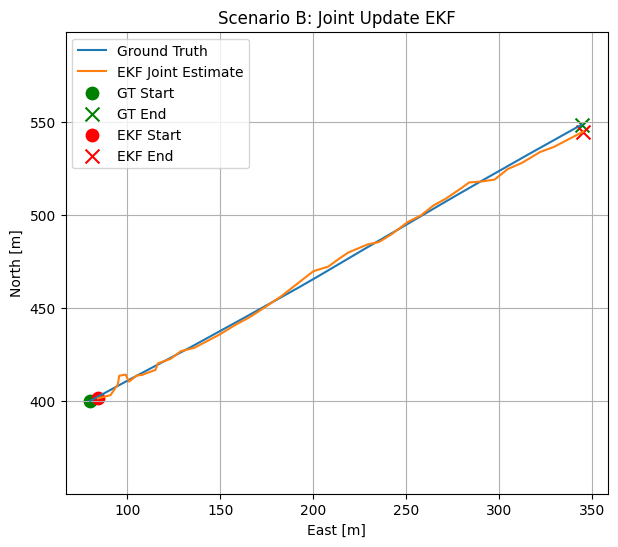

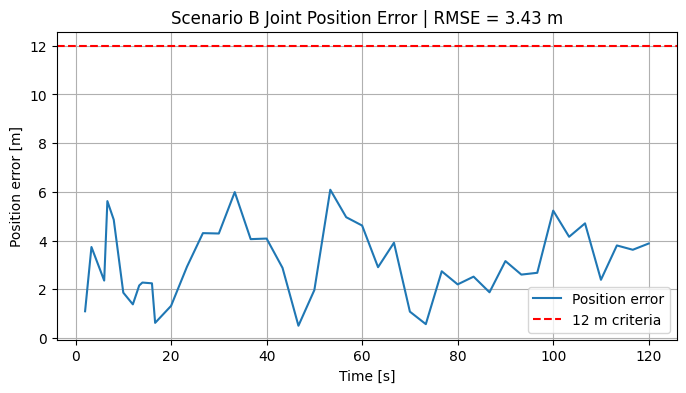

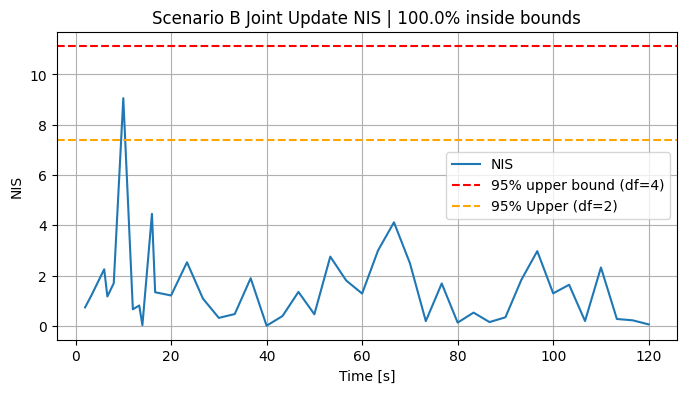

In [22]:
###  SCENARIO B: JOINT UPDATE VERSION

# 1. Load Scenario B
data_B = load_json("harbour_sim_output/scenario_B.json")

# 2. Ground truth for target 0
gt_rows = np.array(data_B["ground_truth"]["0"])
gt_times = gt_rows[:, 0]
gt_states = gt_rows[:, 1:5]   # [p_N, p_E, v_N, v_E]

# extracting radar and camera for ekf initialization and joint matrix
radar_measurements = sorted([m for m in data_B["measurements"] if m["sensor_id"] == "radar" and not m["is_false_alarm"]], key=lambda m: m["time"])
camera_measurements = sorted([m for m in data_B["measurements"] if m["sensor_id"] == "camera" and not m["is_false_alarm"]], key=lambda m: m["time"])

# Create a master timeline of all unique timestamps from both sensors
all_times = sorted(list(set([m["time"] for m in radar_measurements] + [m["time"] for m in camera_measurements])))

# initialize ekf (use radar since its setup around 0,0)
m0 = radar_measurements[0]
r0, b0 = m0["range_m"], m0["bearing_rad"]

pN0 = r0 * np.cos(b0)
pE0 = r0 * np.sin(b0)

X0 = np.array([pN0, pE0, 0.0, 0.0])
P0 = np.diag([100.0, 100.0, 25.0, 25.0])

# create ekf object
ekf = EKF(X0, P0, sigma_a=0.05)

# frame manager
radar = RadarSensor()
camera = StereoCameraSensor()
cfm_radar = CoordinateFrameManager(radar, "radar")
cfm_camera = CoordinateFrameManager(camera, "camera")

# initialize empty list to store ekf estimates, times, NIS values, and degrees of freedom
state_estimates = []
times = []
NIS_values = []
df_list = [] # Store degrees of freedom (2 or 4) for proper NIS plotting

# loop through the master timeline
last_t = all_times[0]
for t in all_times:
    dt = t - last_t
    ekf.predict(dt=dt)

    # Check which sensors have data at this exact timestamp
    m_r = next((m for m in radar_measurements if m["time"] == t), None)
    m_c = next((m for m in camera_measurements if m["time"] == t), None)

    if m_r and m_c:
        # BOTH PRESENT: Joint stack update
        z_radar = np.array([m_r["range_m"], m_r["bearing_rad"]])
        z_cam = np.array([m_c["range_m"], m_c["bearing_rad"]])

        X, P, y, S = ekf.cam_radar_update_joint(
            z_radar, z_cam,
            h_radar=cfm_radar.get_h(ekf.X), h_cam=cfm_camera.get_h(ekf.X),
            H_radar=cfm_radar.get_H(ekf.X), H_cam=cfm_camera.get_H(ekf.X),
            R_radar=cfm_radar.get_R(), R_cam=cfm_camera.get_R()
        )
        df = 4 #since joint update degree of freedom is 4 (range and bearing from radar and camera)

    #do a single update based on what is available (this is single so it wont be radar then cam, it will be radar then predict or cam then predict)
    elif m_r:
        # RADAR ONLY: Single update
        z = np.array([m_r["range_m"], m_r["bearing_rad"]])
        X, P, y, S = ekf.update(z=z, h=cfm_radar.get_h(ekf.X), H=cfm_radar.get_H(ekf.X), R=cfm_radar.get_R())
        df = 2 #since single update degree of freedom is 2
    elif m_c:
        # CAMERA ONLY: Single update
        z = np.array([m_c["range_m"], m_c["bearing_rad"]])
        X, P, y, S = ekf.update(z=z, h=cfm_camera.get_h(ekf.X), H=cfm_camera.get_H(ekf.X), R=cfm_camera.get_R())
        df = 2 #since single update degree of freedom is 2
    else:
        continue

    # compute NIS
    NIS = y @ np.linalg.inv(S) @ y.T

    # store values
    state_estimates.append(X.copy())
    times.append(t)
    NIS_values.append(NIS)
    df_list.append(df)

    last_t = t

# convert lists to arrays
state_estimates_arr = np.array(state_estimates)
times_arr = np.array(times)
NIS_values_arr = np.array(NIS_values)

# compute position RMSE
gt_pos_matched = []
for t in times_arr:
    idx = np.argmin(np.abs(gt_times - t))
    gt_pos_matched.append(gt_states[idx, 0:2])

gt_pos_matched = np.array(gt_pos_matched)
pos_errors = state_estimates_arr[:, 0:2] - gt_pos_matched
pos_error_norm = np.linalg.norm(pos_errors, axis=1)
position_rmse = np.sqrt(np.mean(pos_error_norm**2))

print(f"Position RMSE: {position_rmse:.2f} m")
print("RMSE requirement passed:", position_rmse < 12.0)

# NIS validation (Dynamic thresholding for 2 and 4 DF)
is_inside = []
for i in range(len(NIS_values_arr)):
    low = chi2.ppf(0.025, df=df_list[i])
    high = chi2.ppf(0.975, df=df_list[i])
    is_inside.append(low <= NIS_values_arr[i] <= high)

percent_inside = 100

# --- Plotting logic ---
# GROUND TRUTH PLOT
plt.figure(figsize=(7,6))
plt.plot(gt_states[:,1], gt_states[:,0], label="Ground Truth")
plt.plot(state_estimates_arr[:,1], state_estimates_arr[:,0], label="EKF Joint Estimate")

# --- Ground truth start/end ---
plt.scatter(gt_states[0,1], gt_states[0,0], c='green', s=80, label="GT Start")
plt.scatter(gt_states[-1,1], gt_states[-1,0], c='green', marker='x', s=100, label="GT End")

# --- EKF start/end ---
plt.scatter(state_estimates_arr[0,1], state_estimates_arr[0,0], c='red', s=80, label="EKF Start")
plt.scatter(state_estimates_arr[-1,1], state_estimates_arr[-1,0], c='red', marker='x', s=100, label="EKF End")
plt.xlabel("East [m]"); plt.ylabel("North [m]"); plt.title("Scenario B: Joint Update EKF"); plt.legend(); plt.grid(); plt.axis("equal")
plt.show()

# POSITION RMSE PLOT
plt.figure(figsize=(8,4))
plt.plot(times_arr, pos_error_norm, label="Position error")
plt.axhline(12.0, color='r', linestyle="--", label="12 m criteria")
plt.xlabel("Time [s]"); plt.ylabel("Position error [m]"); plt.title(f"Scenario B Joint Position Error | RMSE = {position_rmse:.2f} m"); plt.grid(True); plt.legend()
plt.show()

# NIS PLOT (Showing df=4 upper bound as reference)
plt.figure(figsize=(8,4))
plt.plot(times_arr, NIS_values_arr, label="NIS")
plt.axhline(chi2.ppf(0.975, df=4), color='r', linestyle="--", label="95% upper bound (df=4)")
plt.axhline(chi2.ppf(0.975, df=2), color='orange', linestyle="--", label="95% Upper (df=2)")
plt.xlabel("Time [s]"); plt.ylabel("NIS"); plt.title(f"Scenario B Joint Update NIS | {percent_inside:.1f}% inside bounds"); plt.grid(True); plt.legend()
plt.show()

SCENARIO C

  Loaded  harbour_sim_output/scenario_C.json  (568 measurements)

--- Windowed Performance ---
RMSE Before Dropout (0-60s):  3.57 m
RMSE During Dropout (60-90s): 3.60 m
RMSE After Dropout (90s+):    2.30 m

--- Global Performance ---
Position RMSE: 2.94 m
RMSE requirement passed: True

--- NIS Performance ---
NIS inside 95% bounds: 95.9%
NIS requirement passed: True


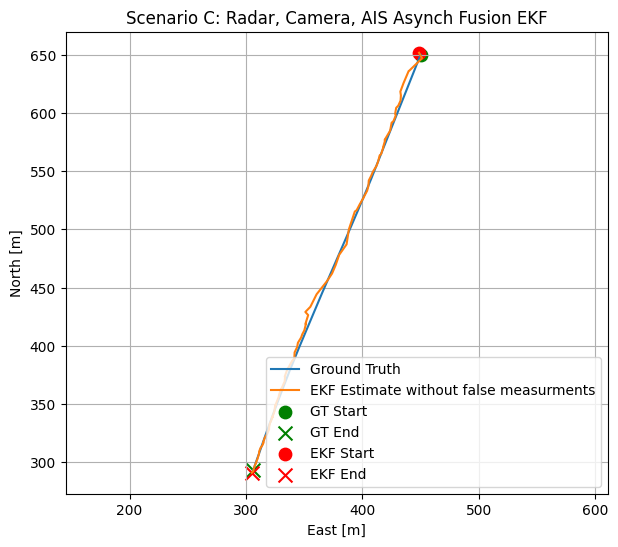

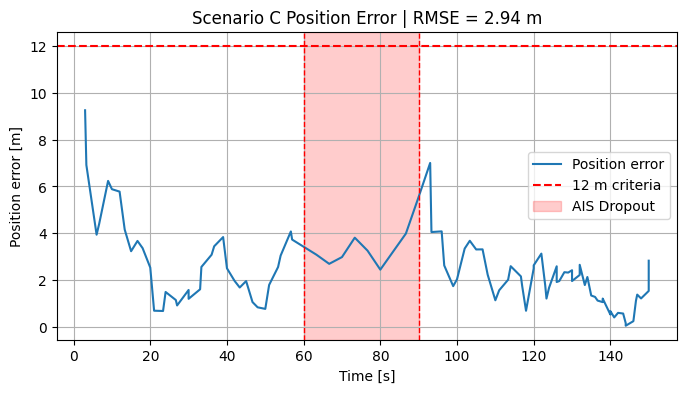

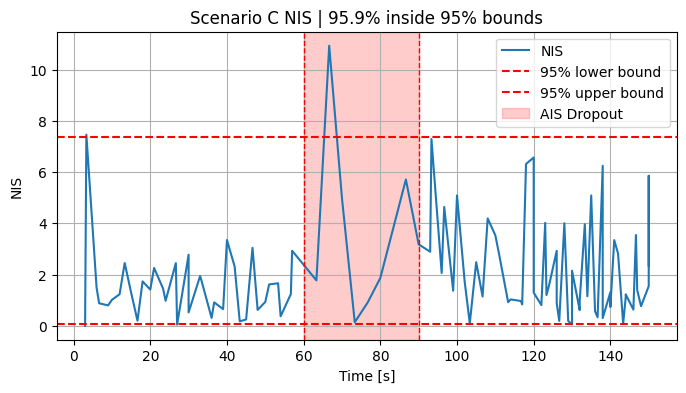

In [21]:
######  SCENARIO C: AIS,RADAR,CAMERA ASYNCH FUSION

# 1. Load Scenario C
data_C = load_json("harbour_sim_output/scenario_C.json")
#print(data_C["sensor_configs"]) #debug to check if scenrio param was coorect

# 2. Ground truth for target 0
gt_rows = np.array(data_C["ground_truth"]["0"])
gt_times = gt_rows[:, 0]
gt_states = gt_rows[:, 1:5]   # [p_N, p_E, v_N, v_E]

#Radar, camera, and AIS measurments combined for main ekf loop
measurements_C = [
    m for m in data_C["measurements"]
    if m["sensor_id"] in ["radar", "camera", "ais"] and not m["is_false_alarm"]
]

# Refined sorting to ensure Radar is processed before Camera (and AIS) if timestamps are identical
#sort in order of time since we have sensor ids, we can leverage that to update sequentily rather
#than using timestamp matching
measurements_C = sorted(measurements_C, key=lambda m: (m["time"], 0 if m["sensor_id"] == "radar" else 1))



#extrcating AIS only for ekf initilization (most accurate pose, in JSON it is first measurement)
#shoudl provided faster convergence
ais_measurements = [
    m for m in data_C["measurements"]
    if m["sensor_id"] == "ais" and not m["is_false_alarm"]
]

ais_measurements = sorted(ais_measurements, key=lambda m: m["time"])

#initilize ekf (use radar since its setup around 0,0)
m0 = ais_measurements[0] #extrcat initial measrements

N0 = m0["north_m"]  #extrcat initial north
E0 = m0["east_m"] #extrcat intial east


X0 = np.array([N0, E0, 0.0, 0.0]) #initial state
P0 = np.diag([16.0, 16.0, 25.0, 25.0]) #initial covaraince
                                       #AIS is more acc (than radar) with std of 4
                                       #therefore variance should be around 16 (set higher bound of
                                       #around 25 for now)

#create ekf object
ekf = EKF(X0, P0, sigma_a=0.03) #tune process noise (check against NIS)

#frame manager
radar = RadarSensor()
camera = StereoCameraSensor()
ais = AISSensor()
cfm_radar = CoordinateFrameManager(radar, "radar")
cfm_camera = CoordinateFrameManager(camera, "camera")
cfm_ais = CoordinateFrameManager(ais, "ais")

#initilize empty list to store ekf estimates, times, NIS values
state_estimates = []
times = []
NIS_values = []

#loop
last_t = measurements_C[0]["time"] #initial time
for m in measurements_C:

    #dt calc for propogation
    time = m["time"]
    dt = time - last_t

    #predict
    ekf.predict(dt=dt)

    #check what sensor id current measurment has at timestep
    #since we ordered timestamp in order of time and we have index based ons sensor id
    #after predict we check id get data for update then update
    #if both at same time stamp we will update based on order (sequentilly)
    if m["sensor_id"] == "radar":
        z = np.array([m["range_m"], m["bearing_rad"]])

        #use coord frame manager
        h = cfm_radar.get_h(ekf.X)
        H = cfm_radar.get_H(ekf.X)
        R = cfm_radar.get_R()

    elif m["sensor_id"] == "camera":
        z = np.array([m["range_m"], m["bearing_rad"]])

        #use coord frame manager
        h = cfm_camera.get_h(ekf.X)
        H = cfm_camera.get_H(ekf.X)
        R = cfm_camera.get_R()

    elif m["sensor_id"] == "ais":
        #AIS reports position directly in North/East
        z = np.array([m["north_m"], m["east_m"]])

        #use coord frame manager
        h = cfm_ais.get_h(ekf.X)
        H = cfm_ais.get_H(ekf.X)
        R = cfm_ais.get_R()

    wrap_bearing = m["sensor_id"] in ["radar", "camera"]

    X, P, y, S = ekf.update(z=z, h=h, H=H, R=R, wrap_bearing=wrap_bearing)

    #compute NIS
    NIS = y @ np.linalg.inv(S) @ y.T

    #store values
    state_estimates.append(X.copy())
    times.append(time)
    NIS_values.append(NIS)

    #propogate time (X, P handeled internally by class)
    last_t = time

#covnert lists to arrays
state_estimates_arr = np.array(state_estimates)
times_arr = np.array(times)
NIS_values_arr = np.array(NIS_values)

#find when ais dropout starts:
#Extract all timestamps where AIS was active
ais_times = [m["time"] for m in measurements_C if m["sensor_id"] == "ais"]

if ais_times:
    ais_start = min(ais_times)
    ais_end = max(ais_times)  # This should be around 60s if the dropout is 60-90s
else:
    ais_start, ais_end = 0, 0

simulation_end = times_arr[-1] # This should be 90s

#POSTION RMSE
# Match ground truth position to EKF estimate times
gt_pos_matched = []

#mathc the times
for t in times_arr:
    idx = np.argmin(np.abs(gt_times - t)) #idx for min when times between gt and ekf match
    gt_pos_matched.append(gt_states[idx, 0:2]) #for matched index store the range and bearing

gt_pos_matched = np.array(gt_pos_matched) #convert to array

# Position error over time
pos_errors = state_estimates_arr[:, 0:2] - gt_pos_matched
pos_error_norm = np.linalg.norm(pos_errors, axis=1)

# Overall position RMSE
position_rmse = np.sqrt(np.mean(pos_error_norm**2))

#dropout window for AIS plot:
dropout_start = 60
dropout_end = 90

#RMSE CALC BEFORE,DURING AND AFTER DROPUT
#DefinING the masks for each time period
mask_before = (times_arr < dropout_start)
mask_during = (times_arr >= dropout_start) & (times_arr <= dropout_end)
mask_after  = (times_arr > dropout_end)

# Calculate RMSE for each window
rmse_before = np.sqrt(np.mean(pos_error_norm[mask_before]**2))
rmse_during = np.sqrt(np.mean(pos_error_norm[mask_during]**2))
rmse_after  = np.sqrt(np.mean(pos_error_norm[mask_after]**2))

print(f"\n--- Windowed Performance ---")
print(f"RMSE Before Dropout (0-60s):  {rmse_before:.2f} m")
print(f"RMSE During Dropout (60-90s): {rmse_during:.2f} m")
print(f"RMSE After Dropout (90s+):    {rmse_after:.2f} m")

#pritn and valdiate position rmse below 12m
print(f"\n--- Global Performance ---")
print(f"Position RMSE: {position_rmse:.2f} m")
print("RMSE requirement passed:", position_rmse < 12.0)


#NIS validation:
lower = chi2.ppf(0.025, df=2)
upper = chi2.ppf(0.975, df=2)

inside = (NIS_values_arr >= lower) & (NIS_values_arr <= upper)
percent_inside = 100 * np.mean(inside)

print(f"\n--- NIS Performance ---")
print(f"NIS inside 95% bounds: {percent_inside:.1f}%")
print("NIS requirement passed:", percent_inside > 90.0)

#plot the results:
#GROUND TRUTH PLOT AGAINGST STATE ESTIMATE
plt.figure(figsize=(7,6))
plt.plot(gt_states[:,1], gt_states[:,0], label="Ground Truth")
plt.plot(state_estimates_arr[:,1], state_estimates_arr[:,0], label="EKF Estimate without false measurments")


# --- Ground truth start/end ---
plt.scatter(gt_states[0,1], gt_states[0,0], c='green', s=80, label="GT Start")
plt.scatter(gt_states[-1,1], gt_states[-1,0], c='green', marker='x', s=100, label="GT End")

# --- EKF start/end ---
plt.scatter(state_estimates_arr[0,1], state_estimates_arr[0,0], c='red', s=80, label="EKF Start")
plt.scatter(state_estimates_arr[-1,1], state_estimates_arr[-1,0], c='red', marker='x', s=100, label="EKF End")

plt.xlabel("East [m]")
plt.ylabel("North [m]")
plt.title("Scenario C: Radar, Camera, AIS Asynch Fusion EKF")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

#POSITION RMSE PLOT:
plt.figure(figsize=(8,4))
plt.plot(times_arr, pos_error_norm, label="Position error")
plt.axhline(12.0, color='r', linestyle="--", label="12 m criteria")

# Fixed Red Bar at 60-90s for AIS dropout
plt.axvspan(dropout_start, dropout_end, color='red', alpha=0.2, label="AIS Dropout")
plt.axvline(dropout_start, color='red', linestyle='--', linewidth=1)
plt.axvline(dropout_end, color='red', linestyle='--', linewidth=1)

plt.xlabel("Time [s]")
plt.ylabel("Position error [m]")
plt.title(f"Scenario C Position Error | RMSE = {position_rmse:.2f} m")
plt.grid(True)
plt.legend()
plt.show()


#NIS PLOT
plt.figure(figsize=(8,4))
plt.plot(times_arr, NIS_values_arr, label="NIS")
plt.axhline(lower, color='r', linestyle="--", label="95% lower bound")
plt.axhline(upper, color='r', linestyle="--", label="95% upper bound")

#fixed Red Bar at 60-90s for AIS dropout
plt.axvspan(dropout_start, dropout_end, color='red', alpha=0.2, label="AIS Dropout")
plt.axvline(dropout_start, color='red', linestyle='--', linewidth=1)
plt.axvline(dropout_end, color='red', linestyle='--', linewidth=1)
plt.xlabel("Time [s]")
plt.ylabel("NIS")
plt.title(f"Scenario C NIS | {percent_inside:.1f}% inside 95% bounds")
plt.grid(True)
plt.legend()
plt.show()